## PARAMETER ESTIMATION NOTEBOOK

In [1]:
# =========================================================================================================================== Import
import time
import os
import shutil

%matplotlib ipympl
from matplotlib import pyplot as plt
from scipy.linalg import solve_continuous_lyapunov, block_diag

import rosbag2_py
from rclpy.serialization import serialize_message, deserialize_message
from sensor_msgs.msg import JointState
import casadi

import numpy as np
from tqdm import tqdm

import pandas as pd

from scipy.signal import butter, filtfilt, savgol_filter

import sys
build_path = "./ahand_finger_generatedFiles_py/build"
if os.path.exists(build_path):
    sys.path.append(os.path.abspath(build_path))
else:
    print(f"Warning: path '{build_path}' does not exist.")

from thunder_ahand_finger_py import thunder_ahand_finger

MESH_DIR = './description/urdf/meshes/'
URDF_PATH = './description/urdf/allegro_hand_description_right_B.urdf'
XML_PATH = './description/urdf/allegro_hand_description_right_B.xml'
BAG_PATH = '/home/leo/Desktop/allegro_hand_ros2_ws/workdir/allegro_hand_test_traject_bag'
NEW_BAG_PATH = '/home/leo/Desktop/allegro_hand_ros2_ws/workdir/allegro_hand_torque_filtered_bag'
CSV_PATH = '/home/leo/Desktop/allegro_hand_ros2_ws/workdir/allegro_log.csv'
JOINT_NAMES = ['joint_4_0', 'joint_5_0', 'joint_6_0', 'joint_7_0']
SAVE_FILENAME = '/home/leo/Desktop/ahand_dynamic_friction.txt'

MASSES_URDF = [0.0176, 0.086, 0.0367, 0.0057] # [Kg]
INERTIAS_URDF = [[1.32064e-05, 1.22498e-05, 2.64678e-06],
                 [5.66968e-05, 4.87935e-05, 1.75097e-05],
                 [1.45504e-05, 1.30076e-05, 3.70193e-06],
                 [5.27679e-06, 4.04675e-06, 2.638e-06]] # [Kg m^2]

np.random.seed(41)


/home/leo/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
# =========================================================================================================================== Define Function
# Bag Read/Write
def read_bag(file_path, topic_name = '/allegroHand_0/joint_states', store=False, path_out=None):
    first = True
    # Open the bag reader
    reader = rosbag2_py.SequentialReader()

    # set options and open the bag
    storage_options = rosbag2_py.StorageOptions(uri=file_path)
    converter_options = rosbag2_py.ConverterOptions('', '')
    reader.open(storage_options, converter_options)

    dataset = []
    header = []
    # scroll the bag
    while reader.has_next():
        (topic, data, t) = reader.read_next()
        if topic == topic_name:
        #if topic == '/allegroHand_0/torque_cmd':
            msg = deserialize_message(data, JointState)
            joint_names = msg.name

            # select specific joints
            indices = [joint_names.index(name) for name in JOINT_NAMES if name in joint_names]
            selected_joint_names = [joint_names[i] for i in indices]
            if first:
                joint_names = msg.name
                # get header
                pos_header    = [f"pos_{name}" for name in selected_joint_names]
                effort_header = [f"eff_{name}" for name in selected_joint_names]
                vel_header    = [f"vel_{name}" for name in selected_joint_names]
                #acc_header    = [f"acc_{name}" for name in selected_joint_names]
                #header = ['t'] + pos_header + vel_header + acc_header + effort_header
                header = ['t'] + pos_header + effort_header + vel_header
                first = False
            elif joint_names != msg.name:
                raise ValueError("Joint names do not match")

            # Store data
            selected_positions = [msg.position[i] for i in indices]
            selected_velocities = [msg.velocity[i] for i in indices]
            selected_effort = [msg.effort[i] for i in indices]
            row = [t/1e9] + selected_positions + selected_effort + selected_velocities
            dataset.append(row)

    # store in dataframe
    df = pd.DataFrame(dataset, columns=header)
    if store:
        df.to_csv(file_path, index=False)

    return df
def read_csv(file_path, joint_names = None, store=False, path_out=None):
    # Read the CSV
    df_raw = pd.read_csv(file_path)

    # Infer joint names if not provided
    if joint_names is None:
        joint_names = sorted(set(
            c.replace('_pos', '').replace('_vel', '').replace('_effort', '')
            for c in df_raw.columns if any(x in c for x in ['_pos', '_vel', '_effort'])
        ))

    # Input column names (from CSV)
    pos_in = [f"{j}_pos" for j in joint_names]
    eff_in = [f"{j}_effort" for j in joint_names]
    vel_in = [f"{j}_vel" for j in joint_names]

    # Output column names (desired format)
    pos_out = [f"pos_{j}" for j in joint_names]
    eff_out = [f"eff_{j}" for j in joint_names]
    vel_out = [f"vel_{j}" for j in joint_names]

    # Build final DataFrame with renamed columns
    df = pd.DataFrame()
    df['t'] = range(len(df_raw))  # add time index
    for in_cols, out_cols in zip([pos_in, eff_in, vel_in], [pos_out, eff_out, vel_out]):
        for ci, co in zip(in_cols, out_cols):
            if ci in df_raw.columns:
                df[co] = df_raw[ci]
            else:
                df[co] = None  # if missing, fill with NaN

    # Optionally store
    if store:
        out_path = path_out or file_path.replace('.csv', '_parsed.csv')
        df.to_csv(out_path, index=False)

    return df

def write_filtered_bag(file_path, t_log, q_log, tau_log, joint_names_filtered):
    if os.path.exists(file_path):
        print(f"Overwriting existing bag: {file_path}")
        shutil.rmtree(file_path)
    all_joint_names = [f'joint_{i}_0' for i in range(15)]
    # Create writer
    writer = rosbag2_py.SequentialWriter()
    storage_options = rosbag2_py.StorageOptions(uri=file_path, storage_id='sqlite3')
    converter_options = rosbag2_py.ConverterOptions('', '')
    writer.open(storage_options, converter_options)

    # Create topic metadata
    topic_name = '/allegroHand_0/torque_cmd'
    topic_type = 'sensor_msgs/msg/JointState'
    writer.create_topic(rosbag2_py.TopicMetadata(name=topic_name,
                                                 type=topic_type,
                                                 serialization_format='cdr'))

    # Map filtered indices to full joint list
    idx_map = [all_joint_names.index(j) if j in all_joint_names else None for j in joint_names_filtered]

    # Write data
    for i in range(len(t_log)):
        msg = JointState()
        msg.header.stamp.sec = int(t_log[i])
        msg.header.stamp.nanosec = int((t_log[i] - int(t_log[i])) * 1e9)
        msg.name = all_joint_names
        # Initialize all zeros
        q_full = np.zeros(15)
        tau_full = np.zeros(15)
        # Fill available joints
        for j, idx in enumerate(idx_map):
            if idx is not None:
                q_full[idx] = q_log[i, j]
                tau_full[idx] = tau_log[i, j]

        msg.position = q_full.tolist()
        msg.effort = tau_full.tolist()
        writer.write(topic_name, serialize_message(msg), int(t_log[i]*1e9))

    print(f"Filtered bag written to {file_path} with all joints 0-14")


# Matrix Eigenvalues
def powerm(v, A, niter): #POWER ITERATION METHOD
    for i in range(niter):
        v = A @ v
        v = v/casadi.norm_2(v)
    l = v.T@A@v
    return v, l
def def_powerm(a, niter=None): #DEFLATION VERSION OF PIM FOR 3X3 MATRIX ---> CALCULATE ALL EIGENVALUES FROM GREATER TO SMALLER
    #AND THEIR EIGENVECTORS
    v0 = casadi.DM([1,1,1])

    if niter is None:
        niter = 40

    v1,l1 = powerm(v0, a, niter)

    v0 = casadi.DM([0,1,1])
    a2 = a - l1*(v1 @ v1.T)
    v2, l2 = powerm(v0, a2, niter)

    v0 = casadi.DM([0,0,1])
    a3 = a2 - l2 * (v2 @ v2.T)
    v3, l3 = powerm(v0, a3, niter)


    D = casadi.vertcat(l1,l2,l3)
    V = casadi.horzcat(v1,v2,v3)
    return V, D
sym_matrix = casadi.SX.sym('M', 3, 3)
eigenvalues = casadi.eig_symbolic(sym_matrix)
f_eigen = casadi.Function('eigen', [sym_matrix], [eigenvalues])
_, eigenvalues = def_powerm(sym_matrix)
f_powerm = casadi.Function('powerm', [sym_matrix], [eigenvalues])
#minimum eigenvalue
def minimum(eigen):
    min = 10000000000000
    for i in range(3):
        min = casadi.if_else(eigen[i] <= min, eigen[i], min)

    return min
def SN(eigen):
    p = 3
    l1 = eigen[0]**(-p)
    l2 = eigen[1]**(-p)
    l3 = eigen[2]**(-p)

    min = (l1 + l2 + l3)**(-1/p)


    return min
def det(A):
    if np.isscalar(A):
        return A
    elif A.shape[0]==1:
        return A[0,0]
    elif A.shape[0]==2:
        return (A[0,0]*A[1,1] - A[1,0]*A[0,1])
    elif A.shape[0]==3:
        return (A[0, 0]*(A[1, 1]*A[2, 2] - A[1, 2]*A[2, 1])
                - A[0, 1]*(A[1, 0]*A[2, 2] - A[1, 2]*A[2, 0])
                + A[0, 2]*(A[1, 0]*A[2, 1] - A[1, 1]*A[2, 0]))
    else:
        raise NotImplementedError("Supported dimensions: 1x1, 2x2, 3x3")
# Skew-symmetric matrix
def skew(v):
    return np.array([[0, -v[2], v[1]],
                     [v[2], 0, -v[0]],
                     [-v[1], v[0], 0]])
def casadi_skew(v):
    return casadi.vertcat(
        casadi.horzcat(0, -v[2], v[1]),
        casadi.horzcat(v[2], 0, -v[0]),
        casadi.horzcat(-v[1], v[0], 0)
    )

# Dynamic Parameters Store/Load
def save_dynamics(filename, hat_Pi, num_joints):
    par_per_link = int(hat_Pi.shape[0]/num_joints)

    masses = [(hat_Pi[i*par_per_link]).item() for i in range(num_joints)]

    CoMs_x = [(hat_Pi[i*par_per_link+1]/masses[i]).item() for i in range(num_joints)]        #pi = m*cx
    CoMs_y = [(hat_Pi[i*par_per_link+2]/masses[i]).item() for i in range(num_joints)]
    CoMs_z = [(hat_Pi[i*par_per_link+3]/masses[i]).item() for i in range(num_joints)]

    Is_xx = [(hat_Pi[i*par_per_link+4] - (masses[i]*CoMs_y[i]**2 - masses[i]*CoMs_z[i]**2)).item()      for i in range(num_joints)]
    Is_xy = [(hat_Pi[i*par_per_link+5] - (masses[i]*CoMs_x[i]*CoMs_y[i])).item()                        for i in range(num_joints)]
    Is_xz = [(hat_Pi[i*par_per_link+5] - (masses[i]*CoMs_x[i]*CoMs_z[i])).item()                        for i in range(num_joints)]
    Is_yy = [(hat_Pi[i*par_per_link+7] - (masses[i]*CoMs_x[i]**2 - masses[i]*CoMs_z[i]**2)).item()   for i in range(num_joints)]
    Is_yz = [(hat_Pi[i*par_per_link+8] - (masses[i]*CoMs_y[i]*CoMs_z[i])).item()   for i in range(num_joints)]
    Is_zz = [(hat_Pi[i*par_per_link+9] - (masses[i]*CoMs_x[i]**2 - masses[i]*CoMs_y[i]**2)).item()   for i in range(num_joints)]
    if par_per_link>10:
        Ds = [(hat_Pi[i*par_per_link+10]).item()        for i in range(n)]
        Fs = [(hat_Pi[i*par_per_link+11]).item()        for i in range(n)]

    with open(filename, 'w') as f:
        f.write("=== Dynamic parameters ======\n")
        f.write(f"PI size: {hat_Pi.shape}\n")
        for i in range(num_joints):
            f.write(f"\tlink {i+1}:\n")
            f.write(f"\t\tinertial:\n")
            f.write(f"\t\t\tsymb: [1,1,1,1,1,1,1,1,1,1]\n")
            f.write(f"\t\t\tmass: {masses[i]}\n")
            f.write(f"\t\t\tCoM_x: {CoMs_x[i]}\n")
            f.write(f"\t\t\tCoM_y: {CoMs_y[i]}\n")
            f.write(f"\t\t\tCoM_z: {CoMs_z[i]}\n")
            f.write(f"\t\t\tIxx: {Is_xx[i]}\n")
            f.write(f"\t\t\tIxy: {Is_xy[i]}\n")
            f.write(f"\t\t\tIxz: {Is_xz[i]}\n")
            f.write(f"\t\t\tIyy: {Is_yy[i]}\n")
            f.write(f"\t\t\tIyz: {Is_yz[i]}\n")
            f.write(f"\t\t\tIzz: {Is_zz[i]}\n")
            if par_per_link>10:
                f.write(f"\t\tfriction:\n")
                f.write(f"\t\t\tsymb: [1,1]\n")
                f.write(f"\t\t\tDl: [{Ds[i]},{Fs[i]}]\n")
        f.write("=============================\n")
def load_dynamics(filename, num_joints): # filename -> (hat_Pi, dict)
    dynamics = {}
    hat_Pi = np.zeros(12*num_joints)
    with open(filename, 'r') as f:
        lines = f.readlines()

    for line in lines:
        line = line.strip()
        if line.startswith('mass:'):
            dynamics.setdefault('mass', []).append(float(line.split(':')[1]))
        elif line.startswith('CoM_x:'):
            dynamics.setdefault('CoM_x', []).append(float(line.split(':')[1]))
        elif line.startswith('CoM_y:'):
            dynamics.setdefault('CoM_y', []).append(float(line.split(':')[1]))
        elif line.startswith('CoM_z:'):
            dynamics.setdefault('CoM_z', []).append(float(line.split(':')[1]))
        elif line.startswith('Ixx:'):
            dynamics.setdefault('Ixx', []).append(float(line.split(':')[1]))
        elif line.startswith('Ixy:'):
            dynamics.setdefault('Ixy', []).append(float(line.split(':')[1]))
        elif line.startswith('Ixz:'):
            dynamics.setdefault('Ixz', []).append(float(line.split(':')[1]))
        elif line.startswith('Iyy:'):
            dynamics.setdefault('Iyy', []).append(float(line.split(':')[1]))
        elif line.startswith('Iyz:'):
            dynamics.setdefault('Iyz', []).append(float(line.split(':')[1]))
        elif line.startswith('Izz:'):
            dynamics.setdefault('Izz', []).append(float(line.split(':')[1]))

    # reconstruct hat_Pi
    hat_Pi[0::12] = dynamics['mass']
    hat_Pi[1::12] = dynamics['CoM_x'] * dynamics['mass']
    hat_Pi[2::12] = dynamics['CoM_y'] * dynamics['mass']
    hat_Pi[3::12] = dynamics['CoM_z'] * dynamics['mass']
    hat_Pi[4::12] = dynamics['Ixx'] + dynamics['mass'] * (dynamics['CoM_y']**2 + dynamics['CoM_z']**2)
    hat_Pi[5::12] = dynamics['Ixy'] + dynamics['mass'] * (dynamics['CoM_x'] * dynamics['CoM_y'])
    hat_Pi[6::12] = dynamics['Ixz'] + dynamics['mass'] * (dynamics['CoM_x'] * dynamics['CoM_z'])
    hat_Pi[7::12] = dynamics['Iyy'] + dynamics['mass'] * (dynamics['CoM_x']**2 + dynamics['CoM_z']**2)
    hat_Pi[8::12] = dynamics['Iyz'] + dynamics['mass'] * (dynamics['CoM_y'] * dynamics['CoM_z'])
    hat_Pi[9::12] = dynamics['Izz'] + dynamics['mass'] * (dynamics['CoM_x']**2 + dynamics['CoM_y']**2)


    return hat_Pi, dynamics

def print_result(hat_Pi, par_per_link):
    masses = [(hat_Pi[i*par_per_link]).item() for i in range(n)]

    CoMs_x = [(hat_Pi[i*par_per_link+1]/masses[i]).item() for i in range(n)]        #pi = m*cx
    CoMs_y = [(hat_Pi[i*par_per_link+2]/masses[i]).item() for i in range(n)]
    CoMs_z = [(hat_Pi[i*par_per_link+3]/masses[i]).item() for i in range(n)]

    Is_xx = [(hat_Pi[i*par_per_link+4] - (masses[i]*CoMs_y[i]**2 - masses[i]*CoMs_z[i]**2)).item()        for i in range(n)]
    Is_xy = [(hat_Pi[i*par_per_link+5] - (masses[i]*CoMs_x[i]*CoMs_y[i])).item()                          for i in range(n)]
    Is_xz = [(hat_Pi[i*par_per_link+5] - (masses[i]*CoMs_x[i]*CoMs_z[i])).item()                          for i in range(n)]
    Is_yy = [(hat_Pi[i*par_per_link+7] - (masses[i]*CoMs_x[i]**2 - masses[i]*CoMs_z[i]**2)).item()        for i in range(n)]
    Is_yz = [(hat_Pi[i*par_per_link+8] - (masses[i]*CoMs_y[i]*CoMs_z[i])).item()                          for i in range(n)]
    Is_zz = [(hat_Pi[i*par_per_link+9] - (masses[i]*CoMs_x[i]**2 - masses[i]*CoMs_y[i]**2)).item()        for i in range(n)]

    if par_per_link>10:
        Ds = [(hat_Pi[i*par_per_link+10]).item()        for i in range(n)]
        Fs = [(hat_Pi[i*par_per_link+11]).item()        for i in range(n)]
    print("=== Dynamic parameters ======")
    print("PI size:", hat_Pi.shape)
    for i in range(thunder_ahand.get_numJoints()):
        print(f"\tlink {i+1}:")
        print(f"\t\tinertial:")
        print(f"\t\t\tsymb: [1,1,1,1,1,1,1,1,1,1]")
        print(f"\t\t\tmass: {masses[i]}")
        print(f"\t\t\tCoM_x: {CoMs_x[i]}")
        print(f"\t\t\tCoM_y: {CoMs_y[i]}")
        print(f"\t\t\tCoM_z: {CoMs_z[i]}")
        print(f"\t\t\tIxx: {Is_xx[i]}")
        print(f"\t\t\tIxy: {Is_xy[i]}")
        print(f"\t\t\tIxz: {Is_xz[i]}")
        print(f"\t\t\tIyy: {Is_yy[i]}")
        print(f"\t\t\tIyz: {Is_yz[i]}")
        print(f"\t\t\tIzz: {Is_zz[i]}")
        if par_per_link>10:
            print(f"\t\tfriction: ")
            print(f"\t\t\tsymb: [1,1]")
            print(f"\t\t\tDl: [{Ds[i]},{Fs[i]}]")
    print("=============================")

Extract Data

In [3]:
# =========================================================================================================================== Start
df = read_bag(BAG_PATH, topic_name='/allegroHand_0/joint_states', store=False)
#df2 = read_bag(BAG_PATH, topic_name='/allegroHand_0/torque_cmd',store=False)

#df = read_csv(CSV_PATH, joint_names=JOINT_NAMES)

[INFO] [1762334803.750188461] [rosbag2_storage]: Opened database '/home/leo/Desktop/allegro_hand_ros2_ws/workdir/allegro_hand_test_traject_bag/allegro_hand_test_traject_bag_0.db3' for READ_ONLY.


In [4]:
# =========================================================================================================================== Process data
INTERVAL = [20, 60]
t0 = df['t'].to_numpy()[0]


df = df[(df['t'] - t0 >= INTERVAL[0]) & (df['t'] - t0 <= INTERVAL[1])]
t_log = df['t'].to_numpy() - t0
q_log = df[[col for col in df.columns if col.startswith('pos_')]].to_numpy()
qd_log = df[[col for col in df.columns if col.startswith('vel_')]].to_numpy()
tau_log = df[[col for col in df.columns if col.startswith('eff_')]].to_numpy()

Dt = np.mean(np.diff(t_log))    # sampling period
F_s = 1.0 / Dt                  # sampling frequency
t_ori = t_log.copy()            # store original data
q_ori = q_log.copy()
qd_ori = qd_log.copy()
tau_ori = tau_log.copy()


"""
df2 = df2[(df2['t'] - t0 >= INTERVAL[0]) & (df2['t'] - t0 <= INTERVAL[1])]
t_log2 = df2['t'].to_numpy() - t0
q_log2 = df2[[col for col in df2.columns if col.startswith('pos_')]].to_numpy()
qd_log2 = df2[[col for col in df2.columns if col.startswith('vel_')]].to_numpy()
tau_log2 = df2[[col for col in df2.columns if col.startswith('eff_')]].to_numpy()
t_ori2 = t_log2.copy()            # store original data
q_ori2 = q_log2.copy()
qd_ori2 = qd_log2.copy()
tau_ori2 = tau_log2.copy()
"""
# 1. Filtering position
""" Savitzy-golay
# Parameters
window_length = 41   # must be odd, ~ window of ~50 ms if fs=1000Hz
polyorder = 3        # polynomial order (2–4 typical)
# Filter position
q_filt = savgol_filter(q_log, window_length=window_length, polyorder=polyorder, axis=0)
# First derivative → velocity
qd_log = savgol_filter(q_log, window_length=window_length, polyorder=polyorder, deriv=1, delta=dt, axis=0)
# Second derivative → acceleration
qdd_log = savgol_filter(q_log, window_length=window_length, polyorder=polyorder, deriv=2, delta=dt, axis=0)
# store filtered joint position
q_ori = q_log
q_log = q_filt
"""

""" moving average filter + finite difference
window_size = 50
# 1. filter position
q_filt = np.convolve(q_log[:,0], np.ones(window_size)/window_size, mode='same').reshape(-1,1)
for i in range(1,q_log.shape[1]):
    # filtering each joint separately
    q_filt_i = np.convolve(q_log[:,i], np.ones(window_size)/window_size, mode='same').reshape(-1,1)
    q_filt = np.hstack((q_filt, q_filt_i))

# discard edges
edge = window_size // 2
q_log = q_filt[edge:-edge,:]
t_log = t_log[edge:-edge]

# 2. First derivative → velocity
qd = np.gradient(q_log, dt, axis=0)
t_vel = t_log.copy()
# filter velocity
qd_filt = np.convolve(qd[:,0], np.ones(window_size)/window_size, mode='same').reshape(-1,1)
for i in range(1, qd.shape[1]):
    # filtering each joint separately
    qd_filt_i = np.convolve(qd[:,i], np.ones(window_size)/window_size, mode='same').reshape(-1,1)
    qd_filt =  np.hstack((qd_filt, qd_filt_i))
# discard edges
t_log = t_log[edge:-edge]
q_log = q_log[edge:-edge,:]
qd_log = qd_filt[edge:-edge,:]

# 3. Second derivative → acceleration
qdd = np.gradient(qd_log, dt, axis=0)
t_acc = t_log.copy()
# filter accedeleration
qdd_filt = np.convolve(qdd[:,0], np.ones(window_size)/window_size, mode='same').reshape(-1,1)
for i in range(1,qd.shape[1]):
    # filtering each joint separately
    qdd_filt_i = np.convolve(qdd[:,i], np.ones(window_size)/window_size, mode='same').reshape(-1,1)
    qdd_filt =  np.hstack((qdd_filt, qdd_filt_i))
# discard edges
t_log = t_log[edge:-edge]
q_log = q_log[edge:-edge,:]
qd_log = qd_log[edge:-edge,:]
qdd_log = qdd_filt[edge:-edge,:]"""

""" Kalman Filtering
"""
class KalmanFilter():
    def __init__(self, sigma_u, sigma_r):
        # state
        self.hat_x = np.zeros((3, 1)) # x = {q, dq, ddq} [rad, rad/s, rad/s^2]
        #self.Pk = 1e-7*np.eye(3,3)
        self.Pk = np.array([[7.43901056e-08, 2.43974556e-05, 4.00077293e-03],
                            [2.43974556e-05, 1.59072400e-02, 3.90492122e+00],
                            [4.00077293e-03, 3.90492122e+00, 1.28068298e+03]])
        # dynamics
        self.Ak = np.array([[0, 1, 0],
                            [0, 0, 1],
                            [0, 0, 0]])
        self.A2k = np.array([[0, 0, 1],
                             [0, 0, 0],
                             [0, 0, 0]])
        self.Hk = np.array([[1, 0, 0]])
        # Kalman values
        self.sigma_u = sigma_u # process noise
        self.Rk = sigma_r * np.eye(1)  # measurement noise

    def prediction(self, dt):
        I = np.eye(3)
        Fd = I + dt*self.Ak + dt*dt/2*self.A2k # discrete transiction
        self.hat_x = Fd @ self.hat_x

        G = np.array([[1/2*dt*dt],
                      [dt],
                      [1]])

        Qk = (self.sigma_u*self.sigma_u)*(G @ G.T)

        self.Pk = Fd @ self.Pk @ Fd.T + Qk

    def update(self, z):
        I = np.eye(3)
        yk = z - self.Hk @ self.hat_x
        Sk = self.Hk @ self.Pk @ self.Hk.T + self.Rk
        Kk = self.Pk @ self.Hk.T @ np.linalg.inv(Sk)
        self.hat_x = self.hat_x + Kk @ yk

        self.Pk = (I - Kk @ self.Hk) @ self.Pk @ (I - Kk @ self.Hk).T + Kk @ self.Rk @ Kk.T

    def get_q(self):
        return self.hat_x[0]
    def get_qd(self):
        return self.hat_x[1]
    def get_qdd(self):
        return self.hat_x[2]

KFs = []
for i in range(4):
    KFs.append(KalmanFilter(25, 1e-7))

q_kf_filt = []
qd_kf_filt = []
qdd_kf_filt = []
q_tmp = []
qd_tmp = []
qdd_tmp = []

for i in range(len(t_log)):
#for i in range(5):
    for j in range(4):
        try:
            dt = t_log[i+1] - t_log[i]
        except:
            ft = t_log[i] - t_log[i-1]
        if i == 0:
            KFs[j].hat_x[0] = q_log[i][j]
        KFs[j].prediction(0.002)
        KFs[j].update(q_log[i][j])

        q_tmp.append(KFs[j].get_q())
        qd_tmp.append(KFs[j].get_qd())
        qdd_tmp.append(KFs[j].get_qdd())

    q_kf_filt.append(np.array(q_tmp))
    qd_kf_filt.append(np.array(qd_tmp))
    qdd_kf_filt.append(np.array(qdd_tmp))
    q_tmp = []
    qd_tmp = []
    qdd_tmp = []


q_kf_filt = np.array(q_kf_filt)
qd_kf_filt = np.array(qd_kf_filt)
qdd_kf_filt = np.array(qdd_kf_filt)

## Butterworth filter + finite difference
## Design Butterworth filter
#order = 4
#cutoff_freq = 1.0  # Hz
#b, a = butter(order, cutoff_freq / (0.5 * f_s), btype='low')
## 1. Filter position
#q_filt = filtfilt(b, a, q_log, axis=0)
#q_log = q_filt
## 2. First derivative → velocity
#qd = np.gradient(q_log, dt, axis=0)
#qd_filt = filtfilt(b, a, qd, axis=0)
#qd_log = qd_filt
#t_vel = t_log.copy()
## 3. Second derivative → acceleration
#qdd = np.gradient(qd_log, dt, axis=0)
#qdd_filt = filtfilt(b, a, qdd, axis=0)
#qdd_log = qdd_filt
#t_acc = t_log.copy()
## 4. commanded torque
#tau_filt = filtfilt(b, a, tau_log, axis=0)
#tau_log = tau_filt

#write_filtered_bag(NEW_BAG_PATH, t_log, q_log, tau_log, JOINT_NAMES)

# Dynamic Model

$ M(q)\ddot{q} + C(q, \dot{q})\dot{q} + G(q) + D \dot{q} + F\text{sign}(\dot{q}) = Y(q, \dot{q}, \ddot{q})\,\pi = \tau $

$ Y(q, \dot{q}, \ddot{q}) \in \mathbb{R}^{n \times 48} $

# Regressor parameters
$ \pi_r^i = \begin{bmatrix} m^i, m^i c^i_x, m^i c^i_x, m^i c^i_x,   J^i_{xx},J^i_{xy},J^i_{xz},J^i_{yy},J^i_{yz},J^i_{zz} \end{bmatrix}'$

$ \pi_d^i = \begin{bmatrix} D^i \end{bmatrix} $

$ \pi_s^i = \begin{bmatrix} F^i \end{bmatrix} $

$ \pi = \begin{bmatrix} \pi^{1'}_r, ..., \pi^{1'}_r | \pi_d^1, ..., \pi_d^n | \pi_s^1, ..., \pi_s^n \end{bmatrix}'$

$ \pi_r \in \mathbb{R}^{40 \times 1}, \pi_d \in \mathbb{R}^{4 \times 1}, \pi_f \in \mathbb{R}^{4 \times 1}$

In [5]:
# =========================================================================================================================== Compute regressor
thunder_ahand = thunder_ahand_finger()
thunder_ahand.load_conf("/home/leo/thunder_dynamics/ahand_finger_generatedFiles/ahand_finger_conf.yaml")

# M(q) ddq + C(q,dq) dq + G(q) + D dq + F sign(dq) = Y(q,dq,ddq) pi = tau
#
# Regressor
#                  |                 |   | __Pi__ |  <- 40
# Y_tot . Pi_tot = |  Y  |  Yd  | Ys | . | _Pi_d_ |  <- 4
#                  |                 |   | _Pi_s_ |  <- 4
#                   ^4x40 ^4x4   ^4x4

Y_log = []
for i in range(t_log.shape[0]):
    #q =q_log[i,:]
    #dq = qd_log[i,:]
    #ddq = qdd_log[i,:]
    q =q_kf_filt[i,:]
    dq = qd_kf_filt[i,:]
    ddq = qdd_kf_filt[i,:]

    thunder_ahand.set_q(q)
    thunder_ahand.set_dq(dq)
    thunder_ahand.set_dqr(dq)
    thunder_ahand.set_ddqr(ddq)
    Y = thunder_ahand.get_reg_M() + thunder_ahand.get_reg_C() + thunder_ahand.get_reg_G()
    #Y_log.append(Y)
    # friction damping and static
    Y_d = np.diag(qd_log[i])
    Y_s = np.diag(2/(1+np.exp(-20*qd_log[i])) - 1)

    # Convert Unit Measures
    Y[:,0:40:10] = Y[:,0:40:10]/1e3                   # [Kg] -> [g]
    Y[:,1:40:10] = Y[:,1:40:10]/(1e6)                 # [Kg*m] -> [g*mm]
    Y[:,2:40:10] = Y[:,2:40:10]/(1e6)                 # [Kg*m] -> [g*mm]
    Y[:,3:40:10] = Y[:,3:40:10]/(1e6)                 # [Kg*m] -> [g*mm]
    Y[:,4:40:10] = Y[:,4:40:10]/(1e9)                 # [Kg*m^2] -> [g*mm^2]
    Y[:,5:40:10] = Y[:,5:40:10]/(1e9)                 # [Kg*m^2] -> [g*mm^2]
    Y[:,6:40:10] = Y[:,6:40:10]/(1e9)                 # [Kg*m^2] -> [g*mm^2]
    Y[:,7:40:10] = Y[:,7:40:10]/(1e9)                 # [Kg*m^2] -> [g*mm^2]
    Y[:,8:40:10] = Y[:,8:40:10]/(1e9)                 # [Kg*m^2] -> [g*mm^2]
    Y[:,9:40:10] = Y[:,9:40:10]/(1e9)                 # [Kg*m^2] -> [g*mm^2]
    Y_log.append(np.hstack([Y, Y_d, Y_s]))


print("> Computing Dynamics param")
M = len(t_log)
n = thunder_ahand.get_numJoints()
print("Number of samples (M): ", M)
YY = np.concatenate([np.asarray(Y) for Y in Y_log], axis=0)
TTau = np.concatenate([np.asarray(t).reshape(n, 1) for t in tau_log], axis=0)

p = Y_log[0].shape[1]
par_per_link = int(p/n)
print("Shape YY (Mnxp): ", YY.shape)
print("Shape TTau (Mnx1): ", TTau.shape)


# Method 1 - Pinv
print("Computing initial guess by pseudoinverse")
print("\t Reducing YY to minimal rank")
print("\t Computing initial guess by pseudoinverse")
hat_Pi = np.linalg.pinv(YY)@TTau
print_result(hat_Pi, par_per_link)


> Computing Dynamics param
Number of samples (M):  19764
Shape YY (Mnxp):  (79056, 48)
Shape TTau (Mnx1):  (79056, 1)
Computing initial guess by pseudoinverse
	 Reducing YY to minimal rank
	 Computing initial guess by pseudoinverse
=== Dynamic parameters ======
PI size: (48, 1)
	link 1:
		inertial:
			symb: [1,1,1,1,1,1,1,1,1,1]
			mass: 0.0
			CoM_x: -inf
			CoM_y: -inf
			CoM_z: -inf
			Ixx: nan
			Ixy: nan
			Ixz: nan
			Iyy: nan
			Iyz: nan
			Izz: nan
		friction: 
			symb: [1,1]
			Dl: [-1.8509818069775433e-05,7498.516816376837]
	link 2:
		inertial:
			symb: [1,1,1,1,1,1,1,1,1,1]
			mass: -3243.4794389513427
			CoM_x: 5.946779942989448e-11
			CoM_y: -108.15203289687074
			CoM_z: -85.80209899176126
			Ixx: 14060036.15490952
			Ixy: -89943.715539358
			Ixz: -89943.71553504709
			Iyy: -23788569.93277458
			Iyz: 30098422.297780123
			Izz: -37938461.06202682
		friction: 
			symb: [1,1]
			Dl: [1042.6264801293728,-127.28198383760704]
	link 3:
		inertial:
			symb: [1,1,1,1,1,1,1,1,1,1]
	

/tmp/ipykernel_8873/3629463580.py:297: RuntimeWarning: divide by zero encountered in divide
  CoMs_x = [(hat_Pi[i*par_per_link+1]/masses[i]).item() for i in range(n)]        #pi = m*cx
/tmp/ipykernel_8873/3629463580.py:298: RuntimeWarning: divide by zero encountered in divide
  CoMs_y = [(hat_Pi[i*par_per_link+2]/masses[i]).item() for i in range(n)]
/tmp/ipykernel_8873/3629463580.py:299: RuntimeWarning: divide by zero encountered in divide
  CoMs_z = [(hat_Pi[i*par_per_link+3]/masses[i]).item() for i in range(n)]


Define standard problem

## Problem Formulation

\begin{aligned}
\min_{\pi} \quad & \| \bar{Y}\,\pi - \bar{\tau} \| \\[6pt]
\text{s.t.} \quad 
& m_i > 0, \quad && \text{(positive link masses)} \\[3pt]
& I^i_{\text{b}} \succ 0, \quad && \text{(positive definite inertia matrices)} \\[3pt]
& \forall\, i = 1, \dots, n
\end{aligned}

## Notes

- $ \bar{Y} \in \mathbb{R}^{Mn \times p}$: regressor matrix
- $ \bar{\tau} \in \mathbb{R}^{Mn} $: measured torques
- $ \pi \in \mathbb{R}^{p} $: stacked dynamic parameters
- $ m_i $: mass of link $i$
- $ I^i_{\text{body}}(\pi) \in \mathbb{S}_+^3 $: inertia tensor of link $i$ (must be positive definite)


In [14]:
# =========================================================================================================================== Define optim problem
# Method 2 - Least Squares
positive_th = 0.001
hat_Pi_sym = casadi.SX.sym('Pi', p, 1)    # Parameters to estimate
g = []          # Constraints
ub = []         # Upper bound
lb = []         # Lower bound


tr = casadi.SX(4,1)
l_min = casadi.SX(4,1)
l_max = casadi.SX(4,1)
d = casadi.SX(4,3)
for i in range(n):
    # Mass must be positive
    g += [hat_Pi_sym[i*10]]
    lb += [MASSES_URDF[i]*990]         # [g]
    ub += [MASSES_URDF[i]*1010]

    # CoM inside a spere of radius r
    cx = hat_Pi_sym[i*10 + 1]/hat_Pi_sym[i*10]
    cy = hat_Pi_sym[i*10 + 2]/hat_Pi_sym[i*10]
    cz = hat_Pi_sym[i*10 + 3]/hat_Pi_sym[i*10]
    c = casadi.vertcat(cx, cy, cz)

    g += [casadi.sqrt(c.T @ c)]
    lb += [0]                    # [mm]
    ub += [100]

    # Semi-definite inertia matrix
    J = casadi.SX(3,3)
    J[0,0] = hat_Pi_sym[i*10 + 4]
    J[0,1] = hat_Pi_sym[i*10 + 5]
    J[0,2] = hat_Pi_sym[i*10 + 6]
    J[1,0] = hat_Pi_sym[i*10 + 5]
    J[1,1] = hat_Pi_sym[i*10 + 7]
    J[1,2] = hat_Pi_sym[i*10 + 8]
    J[2,0] = hat_Pi_sym[i*10 + 6]
    J[2,1] = hat_Pi_sym[i*10 + 8]
    J[2,2] = hat_Pi_sym[i*10 + 9]

    Ib = J - hat_Pi_sym[i*10] * casadi_skew(c) @ casadi_skew(c).T
    tr[i] = Ib[0,0]+Ib[1,1]+Ib[2,2]

    #_, eigen = f_eigen(Ib)
    #l_max[i] = -minimum(-eigen)
    #l_min[i] = minimum(eigen)
    _, eigen = def_powerm(Ib, niter=40)
    #l_max[i] = eigen[0]
    #l_min[i] = eigen[2]
    l_max[i] = -minimum(-eigen)
    l_min[i] = minimum(eigen)
    # !Criterio Sylvestr: det sottomatrici!
    d[i,0] = det(Ib[:3,:3])
    d[i,1] = det(Ib[:2,:2])
    d[i,2] = det(Ib[:1,:1])
    g +=  [d[i,0],      d[i,1],     d[i,2]]
    lb += [0,           0,          0]
    ub += [casadi.inf,  casadi.inf, casadi.inf]
    #g.append(tr[i]/2 - l_max[i])
    #g.append(l[i])

    #lb.append(positive_th)
    #lb.append(0)
    #ub.append(casadi.inf)

    if par_per_link>10:
        # Friction
        # Damping
        g += [hat_Pi_sym[40 + i]]
        lb += [0]
        ub += [2]
        # Static
        g += [hat_Pi_sym[44 + i]]
        lb += [0]
        ub += [2]

# Problem
prob = {}
prob['x'] = hat_Pi_sym
prob['f'] = (YY@hat_Pi_sym - TTau).T @ (YY@hat_Pi_sym - TTau)
prob['g'] = casadi.vertcat(*g)
# Options
opts = {
    "ipopt": {
        "tol": 1e-4,
        "constr_viol_tol": 1e-6,
        "acceptable_tol": 1e-5,
        "dual_inf_tol": 1e-6,
        "compl_inf_tol": 1e-6,
        "max_iter": 15000,
    }
}
#opts = {
#    "ipopt": {
#        "tol": 1e-4,                     # looser tolerances for speed
#        "acceptable_tol": 1e-3,
#        "constr_viol_tol": 1e-4,
#        "max_iter": 3000,
#        "linear_solver": "mumps",        # or "ma57" if available
#        "mu_strategy": "adaptive",
#        "mu_oracle": "probing",
#        "warm_start_init_point": "yes",  # re-use previous solution
#        #"print_level": 0,
#    },
#    #"print_time": 0,
#}
#opts = {
#    "qpsol": "qpoases",   # fast active-set QP solver
#    "qpsol_options": {"printLevel": "none"},
#    "max_iter": 100,
#    "error_on_fail": False,  
#    "print_iteration": False,
#    "print_header": False,
#}
# Solver
solver = casadi.nlpsol('sol', 'ipopt', prob, opts)
#solver = casadi.nlpsol('sol', 'sqpmethod', prob, opts)


In [19]:
# =========================================================================================================================== Solve optim problem
#hat_Pi_0 = np.random.rand(p,1)
hat_Pi_0 = 1*np.ones((p,1))
hat_Pi_0[0:40:10] = np.array(MASSES_URDF).reshape(hat_Pi_0[0:40:10].shape)

hat_Pi_0[1:40:10] = 1*np.ones_like(hat_Pi_0[3:40:10])
hat_Pi_0[2:40:10] = 1*np.ones_like(hat_Pi_0[3:40:10])
hat_Pi_0[3:40:10] = 0*np.ones_like(hat_Pi_0[3:40:10])

hat_Pi_0[4:40:10] = np.array([(INERTIAS_URDF[i][0]) for i in range(n)]).reshape(hat_Pi_0[4:40:10].shape)*np.random.uniform()
hat_Pi_0[7:40:10] = np.array([(INERTIAS_URDF[i][1]) for i in range(n)]).reshape(hat_Pi_0[7:40:10].shape)*np.random.uniform()
hat_Pi_0[9:40:10] = np.array([(INERTIAS_URDF[i][2]) for i in range(n)]).reshape(hat_Pi_0[9:40:10].shape)*np.random.uniform()

# hat_Pi_0 = np.array([[ 1.76000000e-02],
#                     [-1.22793908e-08],
#                     [-1.22793984e-08],
#                     [-8.79994255e-04],
#                     [ 2.34582114e-04],
#                     [ 9.33178120e-09],
#                     [ 2.30046027e-10],
#                     [ 2.34582116e-04],
#                     [ 2.30046165e-10],
#                     [ 9.49576134e-05],
#                     [ 8.68456779e-02],
#                     [-7.40203834e-03],
#                     [-4.53943495e-03],
#                     [ 3.43262015e-08],
#                     [ 2.81026932e-04],
#                     [ 1.43846106e-04],
#                     [-4.25863632e-04],
#                     [-7.67740104e-03],
#                     [ 3.51327307e-05],
#                     [-7.49469116e-03],
#                     [ 3.63369093e-02],
#                     [-1.50928870e-03],
#                     [ 8.03520141e-04],
#                     [-1.10548657e-03],
#                     [ 1.13428455e-04],
#                     [ 2.00268723e-04],
#                     [ 1.18861276e-05],
#                     [-7.84689912e-04],
#                     [ 1.00063436e-05],
#                     [-3.99957449e-04],
#                     [ 5.65061442e-03],
#                     [-4.51937936e-04],
#                     [ 3.37929808e-04],
#                     [-9.71633541e-09],
#                     [ 3.12760462e-04],
#                     [ 1.47102672e-04],
#                     [-1.30560909e-05],
#                     [ 2.03919328e-04],
#                     [ 2.73392745e-06],
#                     [ 2.66948621e-04],
#                     [ 5.54050841e-06],
#                     [ 6.90091799e-05],
#                     [ 5.22313675e-06],
#                     [ 9.97978226e-07],
#                     [ 9.29851897e-06],
#                     [ 2.61363195e-02],
#                     [ 1.54026565e-05],
#                     [ 3.52950985e-06]])

best_resid = 1000000
for i in range(5):
    hat_Pi_0[0:40:10] = hat_Pi_0[0:40:10]*(1e3)*np.random.uniform()                 # [g] -> [Kg]
    hat_Pi_0[1:40:10] = hat_Pi_0[1:40:10]*(1e6)*np.random.uniform()                 # [g*mm] -> [Kg*m]
    hat_Pi_0[2:40:10] = hat_Pi_0[2:40:10]*(1e6)*np.random.uniform()                 # [g*mm] -> [Kg*m]
    hat_Pi_0[3:40:10] = hat_Pi_0[3:40:10]*(1e6)*np.random.uniform()                 # [g*mm] -> [Kg*m]
    hat_Pi_0[4:40:10] = hat_Pi_0[4:40:10]*(1e9)*np.random.uniform()                 # [g*mm^2] -> [Kg*m^2]
    hat_Pi_0[5:40:10] = hat_Pi_0[5:40:10]*(1e9)*np.random.uniform()                 # [g*mm^2] -> [Kg*m^2]
    hat_Pi_0[6:40:10] = hat_Pi_0[6:40:10]*(1e9)*np.random.uniform()                 # [g*mm^2] -> [Kg*m^2]
    hat_Pi_0[7:40:10] = hat_Pi_0[7:40:10]*(1e9)*np.random.uniform()                 # [g*mm^2] -> [Kg*m^2]
    hat_Pi_0[8:40:10] = hat_Pi_0[8:40:10]*(1e9)*np.random.uniform()                 # [g*mm^2] -> [Kg*m^2]
    hat_Pi_0[9:40:10] = hat_Pi_0[9:40:10]*(1e9)*np.random.uniform()                 # [g*mm^2] -> [Kg*m^2]


    sol = solver(x0=hat_Pi_0, lbg=lb,ubg=ub)
    hat_Pi = sol['x'].full()
    #load_dynamics('./res.txt',4)
    resid = YY@hat_Pi - TTau
    if resid < best_resid:
        hat_Pi_Best = hat_Pi.copy()
        best_resid = resid

resid = best_resid
hat_Pi = hat_Pi_Best
print("Residual norm: ", np.linalg.norm(YY@hat_Pi - TTau))

print("> Extracting dinamic parameters")
print(par_per_link)

# reconvert Unit Measures
hat_Pi[0:40:10] = hat_Pi[0:40:10]/(1e3)                   # [g] -> [Kg]
hat_Pi[1:40:10] = hat_Pi[1:40:10]/(1e6)                 # [g*mm] -> [Kg*m]
hat_Pi[2:40:10] = hat_Pi[2:40:10]/(1e6)                 # [g*mm] -> [Kg*m]
hat_Pi[3:40:10] = hat_Pi[3:40:10]/(1e6)                 # [g*mm] -> [Kg*m]
hat_Pi[4:40:10] = hat_Pi[4:40:10]/(1e9)                 # [g*mm^2] -> [Kg*m^2]
hat_Pi[5:40:10] = hat_Pi[5:40:10]/(1e9)                 # [g*mm^2] -> [Kg*m^2]
hat_Pi[6:40:10] = hat_Pi[6:40:10]/(1e9)                 # [g*mm^2] -> [Kg*m^2]
hat_Pi[7:40:10] = hat_Pi[7:40:10]/(1e9)                 # [g*mm^2] -> [Kg*m^2]
hat_Pi[8:40:10] = hat_Pi[8:40:10]/(1e9)                 # [g*mm^2] -> [Kg*m^2]
hat_Pi[9:40:10] = hat_Pi[9:40:10]/(1e9)                 # [g*mm^2] -> [Kg*m^2]

masses = [(hat_Pi[i*10]).item() for i in range(n)]

CoMs_x = [(hat_Pi[i*10+1]/masses[i]).item() for i in range(n)]        # pi  = m*CoM
CoMs_y = [(hat_Pi[i*10+2]/masses[i]).item() for i in range(n)]
CoMs_z = [(hat_Pi[i*10+3]/masses[i]).item() for i in range(n)]

Is_xx = [(hat_Pi[i*10+4] - (masses[i]*CoMs_y[i]**2 - masses[i]*CoMs_z[i]**2)).item()        for i in range(n)]  # pi = J
Is_xy = [(hat_Pi[i*10+5] - (masses[i]*CoMs_x[i]*CoMs_y[i])).item()                          for i in range(n)]
Is_xz = [(hat_Pi[i*10+6] - (masses[i]*CoMs_x[i]*CoMs_z[i])).item()                          for i in range(n)]
Is_yy = [(hat_Pi[i*10+7] - (masses[i]*CoMs_x[i]**2 - masses[i]*CoMs_z[i]**2)).item()        for i in range(n)]
Is_yz = [(hat_Pi[i*10+8] - (masses[i]*CoMs_y[i]*CoMs_z[i])).item()                          for i in range(n)]
Is_zz = [(hat_Pi[i*10+9] - (masses[i]*CoMs_x[i]**2 - masses[i]*CoMs_y[i]**2)).item()        for i in range(n)]

if par_per_link>10:
    Ds = [(hat_Pi[40 + i]).item()        for i in range(n)]
    Fs = [(hat_Pi[44 + i]).item()        for i in range(n)]

print("=== Dynamic parameters ======")
print("PI size:", hat_Pi.shape)
print("PI: \n", hat_Pi)
for i in range(thunder_ahand.get_numJoints()):
    print(f"\tlink {i+1}:")
    print(f"\t\tinertial:")
    print(f"\t\t\tsymb: [1,1,1,1,1,1,1,1,1,1]")
    print(f"\t\t\tmass: {masses[i]}")
    print(f"\t\t\tCoM_x: {CoMs_x[i]}")
    print(f"\t\t\tCoM_y: {CoMs_y[i]}")
    print(f"\t\t\tCoM_z: {CoMs_z[i]}")
    print(f"\t\t\tIxx: {Is_xx[i]}")
    print(f"\t\t\tIxy: {Is_xy[i]}")
    print(f"\t\t\tIxz: {Is_xz[i]}")
    print(f"\t\t\tIyy: {Is_yy[i]}")
    print(f"\t\t\tIyz: {Is_yz[i]}")
    print(f"\t\t\tIzz: {Is_zz[i]}")
    if par_per_link>10:
        print(f"\t\tfriction: ")
        print(f"\t\t\tsymb: [1,1]")
        print(f"\t\t\tDl: [{Ds[i]},{Fs[i]}]")
print("=============================")

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:      112
Number of nonzeros in Lagrangian Hessian.............:      676

Total number of variables............................:       48
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:       28
        inequality constraints with only lower bounds:       12
   inequality constraints with lower and upper bounds:       16
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  3.1130352e+08 1.02e+20 5.00e+01  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

Define iterative problem

In [6]:
# ================================================================================================================ (ITERATVE) Define optim problem
# Method 2 - Least Squares
hat_Pi_sym = casadi.SX.sym('Pi', p, 1)    # Parameters to estimate
xi_k = casadi.SX.sym('xi_k', 1, 1)        # constraint hardness parameters
nhg = []        # No-Hard Constraints
g = []          # Constraints
ub = []         # Upper bound
lb = []         # Lower bound

# Masses limit
Mmax = 1000*(np.sum(MASSES_URDF) + 0.01) # [Kg]
Mmin = 1000*(np.sum(MASSES_URDF) - 0.01) # [Kg]
M_tot = hat_Pi_sym[0] + hat_Pi_sym[10] + hat_Pi_sym[20] + hat_Pi_sym[30]
nhg += [-minimum(casadi.horzcat(0, Mmax - M_tot, M_tot - Mmin))]
# Inertia semidefinite
tr = casadi.SX(4,1)
l_max = casadi.SX(4,1)
for i in range(4):
    # CoM inside a spere of radius r
    cx = hat_Pi_sym[i*10 + 1]/hat_Pi_sym[i*10]
    cy = hat_Pi_sym[i*10 + 2]/hat_Pi_sym[i*10]
    cz = hat_Pi_sym[i*10 + 3]/hat_Pi_sym[i*10]
    c = casadi.vertcat(cx, cy, cz)
    # Semi-definite inertia matrix
    J = casadi.SX(3,3)
    J[0,0] = hat_Pi_sym[i*10 + 4]
    J[0,1] = hat_Pi_sym[i*10 + 5]
    J[0,2] = hat_Pi_sym[i*10 + 6]
    J[1,0] = hat_Pi_sym[i*10 + 5]
    J[1,1] = hat_Pi_sym[i*10 + 7]
    J[1,2] = hat_Pi_sym[i*10 + 8]
    J[2,0] = hat_Pi_sym[i*10 + 6]
    J[2,1] = hat_Pi_sym[i*10 + 8]
    J[2,2] = hat_Pi_sym[i*10 + 9]
    Ib = J - hat_Pi_sym[i*10] * casadi_skew(c) @ casadi_skew(c).T

    tr[i] = Ib[0,0] + Ib[1,1] + Ib[2,2]
    eigenvalues = f_eigen(Ib)
    l_max[i] = - minimum(-eigenvalues)
    nhg += [-minimum(casadi.horzcat(0, tr[i]/2 - l_max[i], casadi.inf))]

# HARD CONSTRAINT
# 1) Masses [Kg]
g += [hat_Pi_sym[0],        hat_Pi_sym[10],       hat_Pi_sym[20],       hat_Pi_sym[30]]
lb += [1000*MASSES_URDF[0], 1000*MASSES_URDF[1], 1000*MASSES_URDF[2], 1000*MASSES_URDF[3]]
ub += [1000*MASSES_URDF[0], 1000*MASSES_URDF[1], 1000*MASSES_URDF[2], 1000*MASSES_URDF[3]]


# 2) CoM [m]
# CoM inside a spere of radius r
for i in range(4):
    cx = hat_Pi_sym[10*i + 1]/hat_Pi_sym[10*i + 0]
    cy = hat_Pi_sym[10*i + 2]/hat_Pi_sym[10*i + 0]
    cz = hat_Pi_sym[10*i + 3]/hat_Pi_sym[10*i + 0]
    g += [cx,   cy,   cz]
    lb+= [-10, -10, -10]
    ub+= [ 10,  10,  10]
nhg = casadi.vertcat(*nhg)

# Problem
prob = {}
prob['x'] = hat_Pi_sym
prob['p'] = xi_k
prob['f'] = (YY@hat_Pi_sym - TTau).T @ (YY@hat_Pi_sym - TTau) + xi_k * casadi.sum(nhg)
prob['g'] = casadi.vertcat(*g)
# Options
opts = {
    "ipopt": {
        "tol": 1e-6,
        "constr_viol_tol": 1e-6,
        "acceptable_tol": 1e-5,
        "dual_inf_tol": 1e-6,
        "compl_inf_tol": 1e-6,
        "max_iter": 3000,
    }
}

tole = 10 ** -4
opts = {'ipopt': {'linear_solver': 'ma57', 'tol': tole,'hessian_approximation': 'limited-memory'}}
opts = {
    "ipopt": {
        "tol": 1e-4,
        "constr_viol_tol": 1e-6,
        "acceptable_tol": 1e-5,
        "dual_inf_tol": 1e-6,
        "compl_inf_tol": 1e-6,
        "max_iter": 15000,
    }
}
# Solver
iter_solver = casadi.nlpsol('sol', 'ipopt', prob, opts)

In [13]:
# =========================================================================================================================== Solve optim problem
hat_Pi_0 = np.ones((p,1))
hat_Pi_0[0] = lb[0] - (ub[0] + lb[0])*np.random.uniform() # masses
hat_Pi_0[10] = lb[1] - (ub[1] + lb[1])*np.random.uniform()
hat_Pi_0[20] = lb[2] - (ub[2] + lb[2])*np.random.uniform()
hat_Pi_0[30] = lb[3] - (ub[3] + lb[3])*np.random.uniform()
for i in range(4):
    hat_Pi_0[i*10 + 4] = lb[3*i + 4] - (ub[3*i + 4] + lb[3*i + 4])*np.random.uniform() # cx
    hat_Pi_0[i*10 + 5] = lb[3*i + 5] - (ub[3*i + 5] + lb[3*i + 5])*np.random.uniform() # cy
    hat_Pi_0[i*10 + 6] = lb[3*i + 6] - (ub[3*i + 6] + lb[3*i + 6])*np.random.uniform() # cz

for k in range(3):
     print(f"Step k = {k}")
     sol = iter_solver(x0=hat_Pi_0, p=10*k, lbg=lb,ubg=ub)
     hat_Pi_0 = sol['x'].full()
hat_Pi = hat_Pi_0

#sol = iter_solver(x0=hat_Pi_0, p=100, lbg=lb,ubg=ub)
#hat_Pi = sol['x'].full()

resid = YY@hat_Pi - TTau
print("Residual norm: ", np.linalg.norm(YY@hat_Pi - TTau))

print("> Extracting dinamic parameters")
print(par_per_link)

# reconvert Unit Measures
hat_Pi[0:40:10] = hat_Pi[0:40:10]/1e3                   # [g] -> [Kg]
hat_Pi[1:40:10] = hat_Pi[1:40:10]/(1e6)                 # [g*mm] -> [Kg*m]
hat_Pi[2:40:10] = hat_Pi[2:40:10]/(1e6)                 # [g*mm] -> [Kg*m]
hat_Pi[3:40:10] = hat_Pi[3:40:10]/(1e6)                 # [g*mm] -> [Kg*m]
hat_Pi[4:40:10] = hat_Pi[4:40:10]/(1e9)                 # [g*mm^2] -> [Kg*m^2]
hat_Pi[5:40:10] = hat_Pi[5:40:10]/(1e9)                 # [g*mm^2] -> [Kg*m^2]
hat_Pi[6:40:10] = hat_Pi[6:40:10]/(1e9)                 # [g*mm^2] -> [Kg*m^2]
hat_Pi[7:40:10] = hat_Pi[7:40:10]/(1e9)                 # [g*mm^2] -> [Kg*m^2]
hat_Pi[8:40:10] = hat_Pi[8:40:10]/(1e9)                 # [g*mm^2] -> [Kg*m^2]
hat_Pi[9:40:10] = hat_Pi[9:40:10]/(1e9)                 # [g*mm^2] -> [Kg*m^2]

masses = [(hat_Pi[i*10]).item() for i in range(n)]

CoMs_x = [(hat_Pi[i*10+1]/masses[i]).item() for i in range(n)]        # pi  = m*CoM
CoMs_y = [(hat_Pi[i*10+2]/masses[i]).item() for i in range(n)]
CoMs_z = [(hat_Pi[i*10+3]/masses[i]).item() for i in range(n)]

Is_xx = [(hat_Pi[i*10+4] - (masses[i]*CoMs_y[i]**2 - masses[i]*CoMs_z[i]**2)).item()        for i in range(n)]  # pi = J
Is_xy = [(hat_Pi[i*10+5] - (masses[i]*CoMs_x[i]*CoMs_y[i])).item()                          for i in range(n)]
Is_xz = [(hat_Pi[i*10+6] - (masses[i]*CoMs_x[i]*CoMs_z[i])).item()                          for i in range(n)]
Is_yy = [(hat_Pi[i*10+7] - (masses[i]*CoMs_x[i]**2 - masses[i]*CoMs_z[i]**2)).item()        for i in range(n)]
Is_yz = [(hat_Pi[i*10+8] - (masses[i]*CoMs_y[i]*CoMs_z[i])).item()                          for i in range(n)]
Is_zz = [(hat_Pi[i*10+9] - (masses[i]*CoMs_x[i]**2 - masses[i]*CoMs_y[i]**2)).item()        for i in range(n)]

if par_per_link>10:
    Ds = [(hat_Pi[40 + i]).item()        for i in range(n)]
    Fs = [(hat_Pi[44 + i]).item()        for i in range(n)]

print("=== Dynamic parameters ======")
print("PI size:", hat_Pi.shape)
print("PI = ", hat_Pi)
for i in range(thunder_ahand.get_numJoints()):
    print(f"\tlink {i+1}:")
    print(f"\t\tinertial:")
    print(f"\t\t\tsymb: [1,1,1,1,1,1,1,1,1,1]")
    print(f"\t\t\tmass: {masses[i]}")
    print(f"\t\t\tCoM_x: {CoMs_x[i]}")
    print(f"\t\t\tCoM_y: {CoMs_y[i]}")
    print(f"\t\t\tCoM_z: {CoMs_z[i]}")
    print(f"\t\t\tIxx: {Is_xx[i]}")
    print(f"\t\t\tIxy: {Is_xy[i]}")
    print(f"\t\t\tIxz: {Is_xz[i]}")
    print(f"\t\t\tIyy: {Is_yy[i]}")
    print(f"\t\t\tIyz: {Is_yz[i]}")
    print(f"\t\t\tIzz: {Is_zz[i]}")
    if par_per_link>10:
        print(f"\t\tfriction: ")
        print(f"\t\t\tsymb: [1,1]")
        print(f"\t\t\tDl: [{Ds[i]},{Fs[i]}]")
print("=============================")

Step k = 0
This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        4
Number of nonzeros in inequality constraint Jacobian.:       24
Number of nonzeros in Lagrangian Hessian.............:      689

Total number of variables............................:       48
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        4
Total number of inequality constraints...............:       12
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:       12
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  3.3321805e+05 1.11e+02 1.00e+02  -1.0 0.00e+00    -  0.00e+0

CasADi - 2025-11-05 10:37:24 WARNING("sol:nlp_grad_f failed: NaN detected for output grad_f_x, at (row 20, col 0).") [.../casadi/core/oracle_function.cpp:408]


Verifie the solution

In [8]:
# =========================================================================================================================== Compute tau_hat
thunder_ahand.set_par_DYN(hat_Pi[:40])
delta_tau = []
for i in range(len(t_log)):
    #q =q_log[i,:]
    #dq = qd_log[i,:]
    #ddq = qdd_log[i,:]
    q = q_kf_filt[i,:]
    dq = qd_kf_filt[i,:]
    ddq = qdd_kf_filt[i,:]

    thunder_ahand.set_q(q)
    thunder_ahand.set_dq(dq)
    thunder_ahand.set_dqr(dq)
    thunder_ahand.set_ddqr(ddq)
    Y = thunder_ahand.get_reg_M() + thunder_ahand.get_reg_C() + thunder_ahand.get_reg_G()
    # add friction damping and static
    Y_d = np.diag(dq.flatten())
    Y_s = np.diag((2/(1+np.exp(-20*dq)) - 1).flatten())
    Y = np.hstack([Y, Y_d, Y_s])

    tau_est = np.array(Y @ hat_Pi).flatten()
    delta_tau.append(tau_log[i,:] - tau_est)
delta_tau = np.array(delta_tau)

In [9]:
for i in range(4):
    # CoM inside a spere of radius r
    cx = hat_Pi[i*10 + 1]/hat_Pi[i*10]
    cy = hat_Pi[i*10 + 2]/hat_Pi[i*10]
    cz = hat_Pi[i*10 + 3]/hat_Pi[i*10]
    c = np.array([cx.item(),cy.item(),cz.item()])
    #print(skew(c))
    # Semi-definite inertia matrix
    Jxx = hat_Pi[i*10 + 4].item()
    Jxy = hat_Pi[i*10 + 5].item()
    Jxz = hat_Pi[i*10 + 6].item()
    Jyy = hat_Pi[i*10 + 7].item()
    Jyz = hat_Pi[i*10 + 8].item()
    Jzz = hat_Pi[i*10 + 9].item()
    J = np.array([[Jxx, Jxy, Jxz],
                   [Jxy, Jyy, Jyz],
                   [Jxz, Jyz, Jzz]])
    Ib = J - hat_Pi[i*10] * skew(c) @ skew(c).T

    l_eig, _ = np.linalg.eig(Ib)
    _,l = def_powerm(Ib, niter=40)
    #g.append((Ib[0,0]+Ib[1,1]+Ib[2,2])/2 - l[0])

    d_1 = det(Ib[:3,:3])
    d_2 = det(Ib[:2,:2])
    d_3 = det(Ib[:1,:1])
    print(d_1)
    print(d_2)
    print(d_3)

    print(l)
    print(l_eig)
    print(minimum(l))
    print((Ib[0,0]+Ib[1,1]+Ib[2,2])/2 - l[0])
    #print(Ib)
    #print(J)
    print("")

3.657826551788032e-25
7.168870655051124e-17
1.0358060503526685e-08
[1.06507e-08, 9.44012e-09, 3.63871e-09]
[1.06577702e-08 9.43210902e-09 3.63871420e-09]
3.63871e-09
1.21362e-09

3.616433637855537e-25
6.840924770204425e-17
1.016033198387252e-08
[1.01861e-08, 9.67568e-09, 3.67102e-09]
[3.67101548e-09 1.02253954e-08 9.63416704e-09]
3.67102e-09
1.57917e-09

2.031032217253936e-25
5.422936689066202e-17
9.506090793335662e-09
[1.04036e-08, 7.94714e-09, 2.45652e-09]
[1.04036507e-08 7.94712811e-09 2.45652301e-09]
2.45652e-09
9.21703e-15

1.3975989917924412e-25
3.6645933439654484e-17
5.846244482390593e-09
[7.36318e-09, 5.35134e-09, 3.54695e-09]
[7.36317707e-09 5.35133823e-09 3.54694891e-09]
3.54695e-09
7.67555e-10



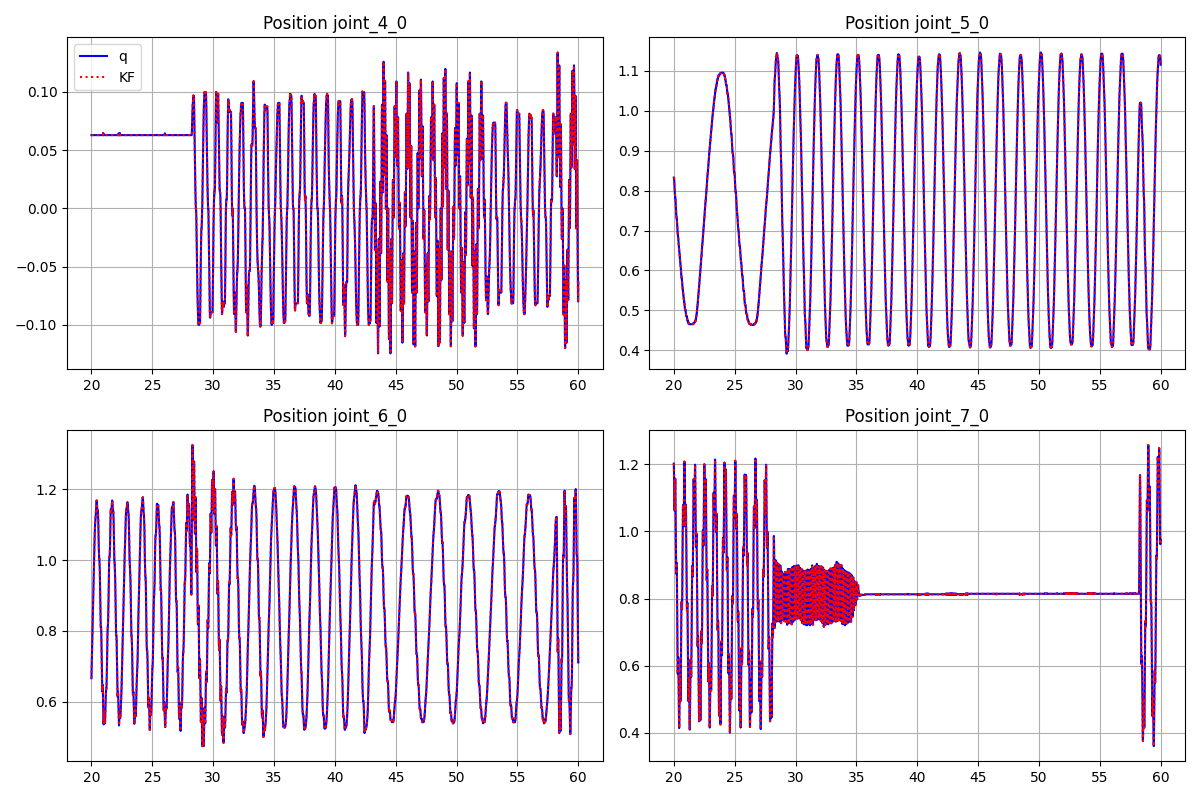

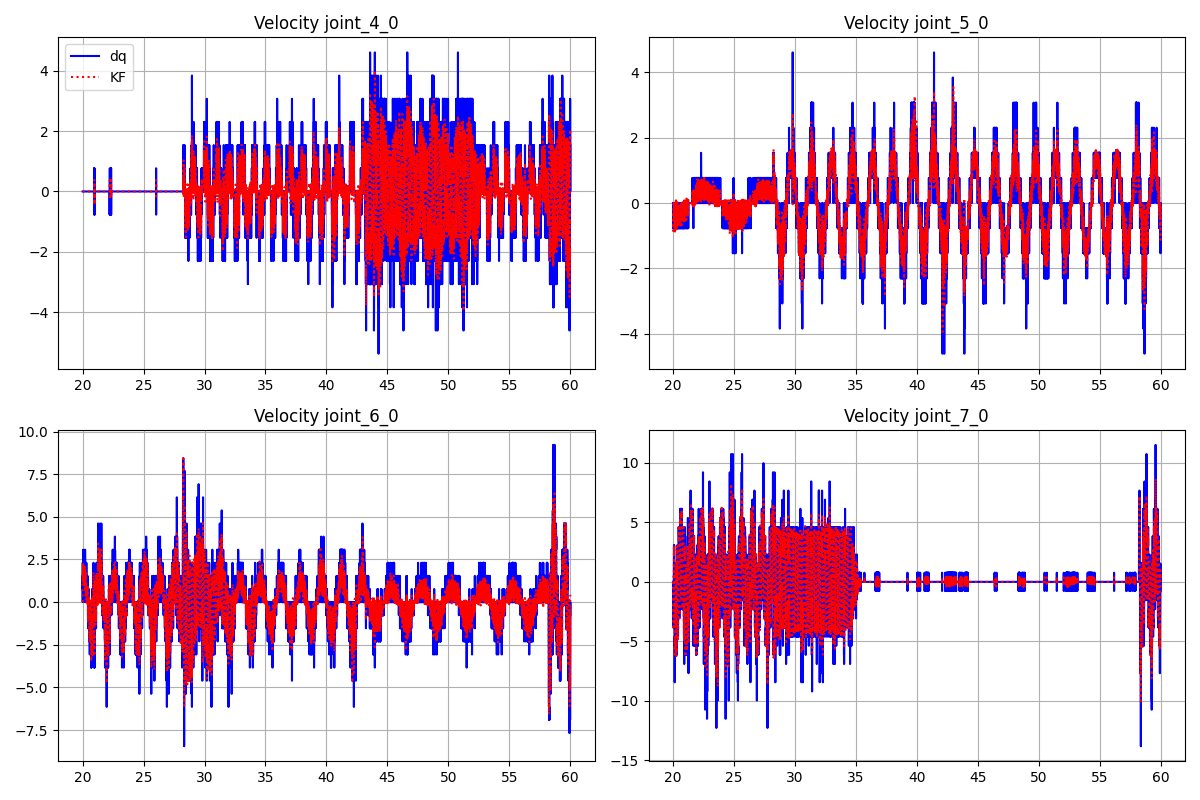

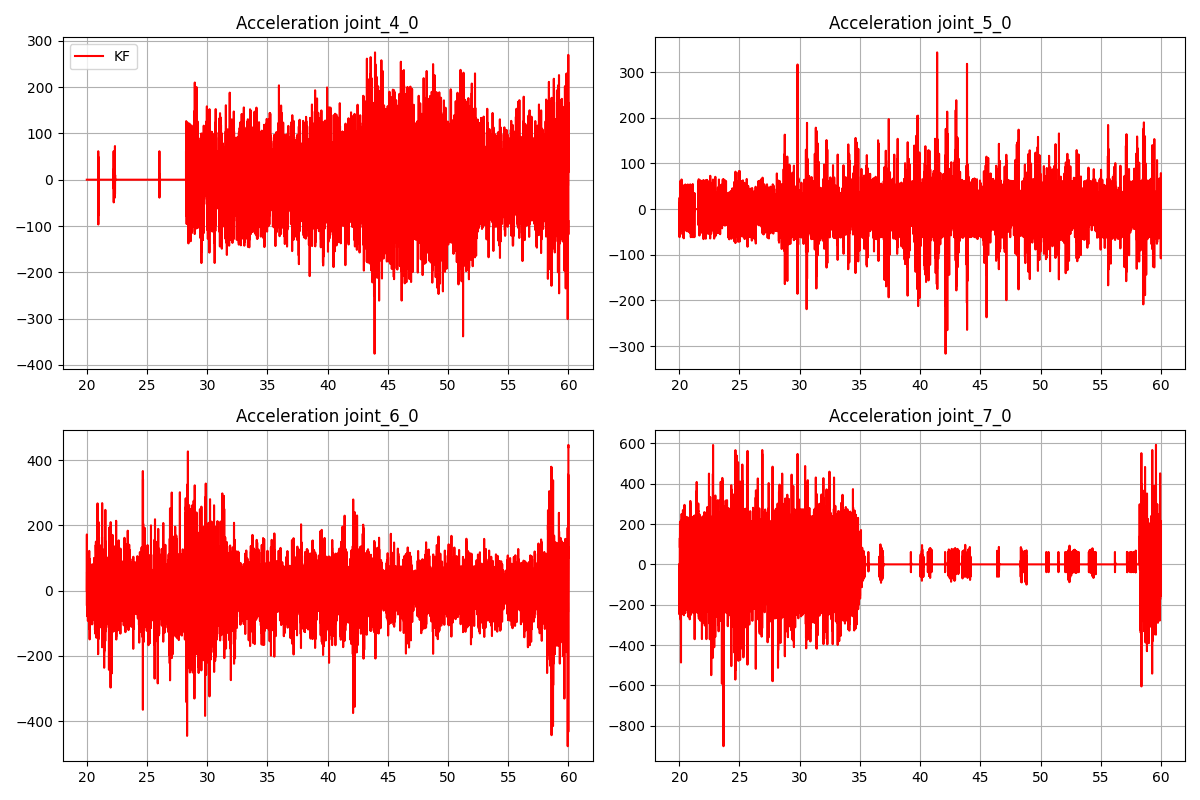

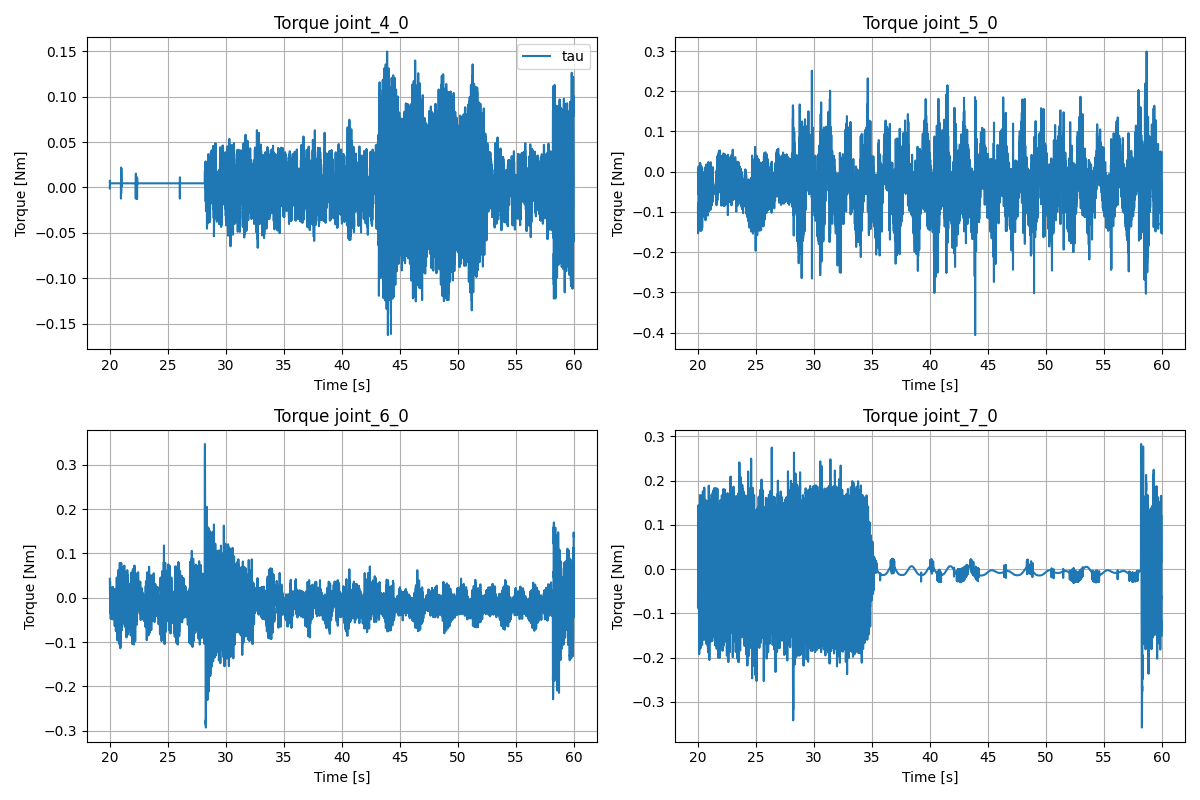

In [10]:
# =========================================================================================================================== Plot
# --- 1. Plot joint trajectories ---
plt.figure(figsize=(12,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.plot(t_log, q_ori[:,i], 'b', label='q')
    #plt.plot(t_log, q_log[:,i], 'r', label='q_filt')
    try:
        plt.plot(t_log2, q_log2[:,i], 'g', label='q_filt')
    except:
        pass
    plt.plot(t_log, q_kf_filt[:,i], 'r', linestyle='dotted', label='KF')
    #plt.plot(t_log, q_log[:,i] - e_log[:,i], 'b', linestyle='dotted', label='q_ref')# Plot joint desired trajectory
    #plt.hlines(JOINT_LIMITS[joint_indices[i], 0], t_log[0], t_log[-1], colors='k', linestyles='dotted', linewidth=1)
    #plt.hlines(JOINT_LIMITS[joint_indices[i], 1], t_log[0], t_log[-1], colors='k', linestyles='dotted', linewidth=1)
    plt.title(f'Position {JOINT_NAMES[i]}')
    plt.grid(True)
    if i==0:
        plt.legend()
plt.tight_layout()
plt.show()
# --- 1. Plot joint trajectories ---
plt.figure(figsize=(12,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.plot(t_log, qd_ori[:,i], 'b', label='dq')
    try:
        plt.plot(t_log2, qd_log2[:,i], 'g', label='q_filt')
    except:
        pass
    #plt.plot(t_log, qd_log[:,i], 'r', label='dq_filt')
    plt.plot(t_log, qd_kf_filt[:,i], 'r', linestyle='dotted', label='KF')
    plt.title(f'Velocity {JOINT_NAMES[i]}')
    plt.grid(True)
    if i==0:
        plt.legend()
plt.tight_layout()
plt.show()
plt.figure(figsize=(12,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    #plt.plot(t_log, qdd[:,i], 'b', label='ddq')
    #plt.plot(t_log, qdd_log[:,i], 'r', label='ddq_filt')
    plt.plot(t_log, qdd_kf_filt[:,i], 'r', label='KF')
    plt.title(f'Acceleration {JOINT_NAMES[i]}')
    plt.grid(True)
    if i==0:
        plt.legend()
plt.tight_layout()
plt.show()

# --- 2. Plot joint tau ---
plt.figure(figsize=(12,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.plot(t_log, tau_ori[:,i], label = 'tau')
    plt.xlabel('Time [s]')
    plt.ylabel('Torque [Nm]')
    plt.title(f'Torque {JOINT_NAMES[i]}')
    plt.grid(True)
    if i==0:
        plt.legend()
plt.tight_layout()
plt.show(block=False)

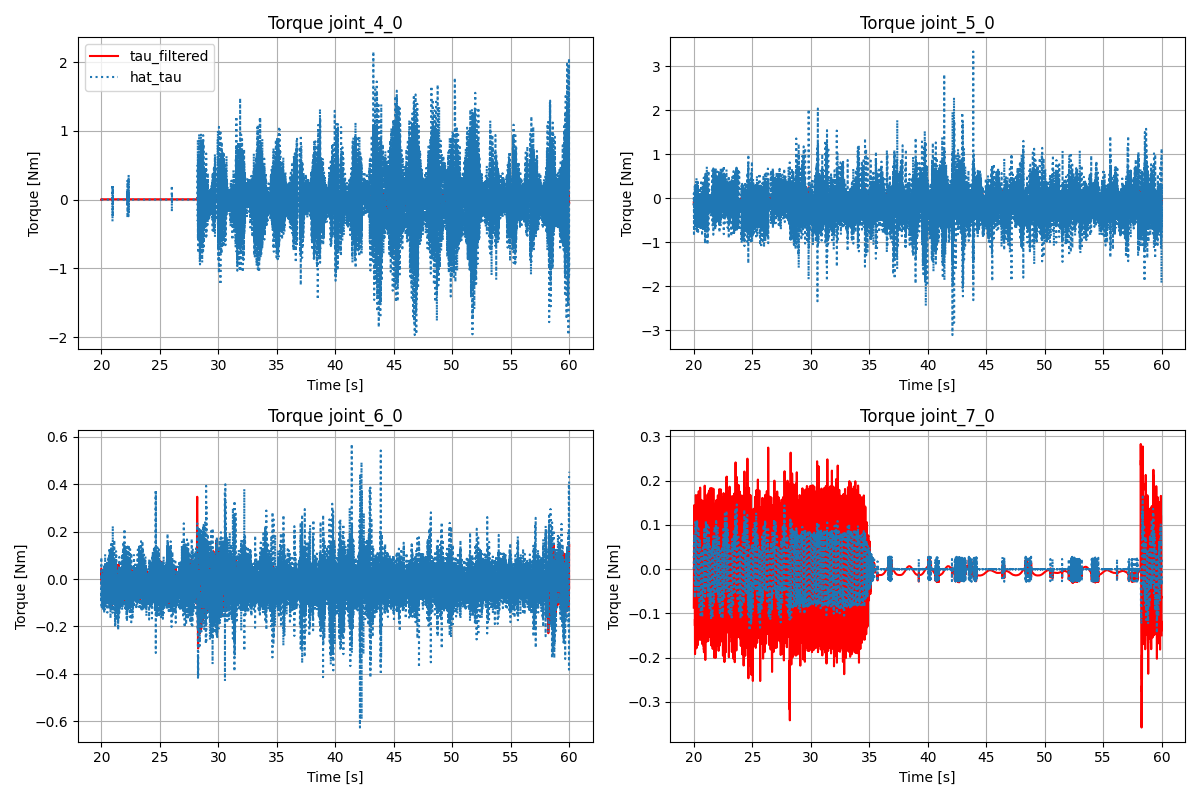

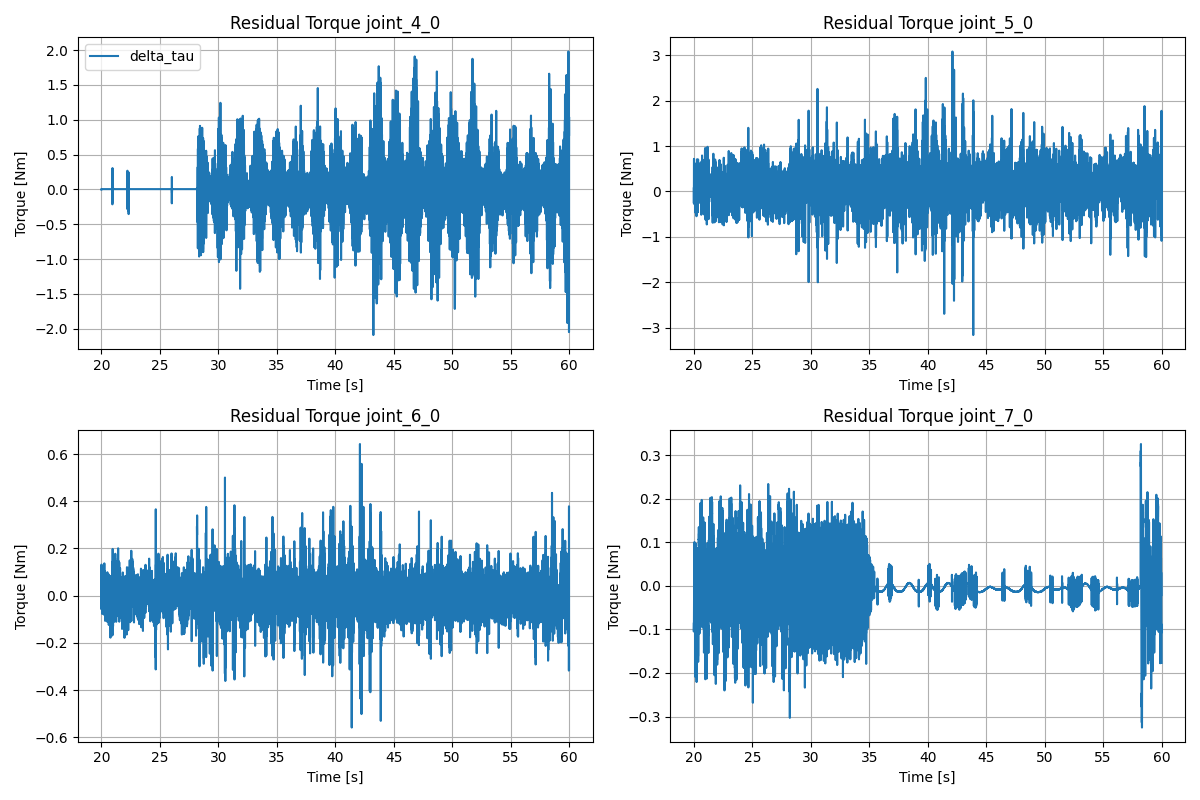

In [11]:
# =========================================================================================================================== Plot
# --- 1. Plot joint trajectories ---
plt.figure(figsize=(12,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    #plt.plot(t_log, tau_ori[:,i], label = 'tau')
    plt.plot(t_log, tau_log[:,i], 'r', label = 'tau_filtered')
    plt.plot(t_log, tau_log[:,i] - delta_tau[:,i], linestyle='dotted', label = 'hat_tau')
    plt.xlabel('Time [s]')
    plt.ylabel('Torque [Nm]')
    plt.title(f'Torque {JOINT_NAMES[i]}')
    plt.grid(True)
    if i==0:
        plt.legend()
plt.tight_layout()
plt.show(block=False)

# --- 3. Plot delta torques ---
plt.figure(figsize=(12,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.plot(t_log, delta_tau[:,i], label = 'delta_tau')
    plt.xlabel('Time [s]')
    plt.ylabel('Torque [Nm]')
    plt.title(f'Residual Torque {JOINT_NAMES[i]}')
    plt.grid(True)
    if i==0:
        plt.legend()
plt.tight_layout()
plt.show(block=False)

# --- 3. Plot delta torques ---
# plt.figure(figsize=(12,8))
# for i in range(4):
#     plt.subplot(2,2,i+1)
#     plt.plot(t_log, resid[i::4], label = 'delta_tau')
#     plt.xlabel('Time [s]')
#     plt.ylabel('Torque [Nm]')
#     plt.title(f'Joint {JOINT_NAMES[i]}')
#     plt.grid(True)
#     if i==0:
#         plt.legend()
# plt.tight_layout()
# plt.show()

# Verifie 2

In [45]:
INTERVAL = [12, 14]
SAVE = False

[INFO] [1762261912.848598950] [rosbag2_storage]: Opened database '/home/leo/Desktop/allegro_hand_ros2_ws/workdir/allegro_hand_test_traject_bag/allegro_hand_test_traject_bag_0.db3' for READ_ONLY.


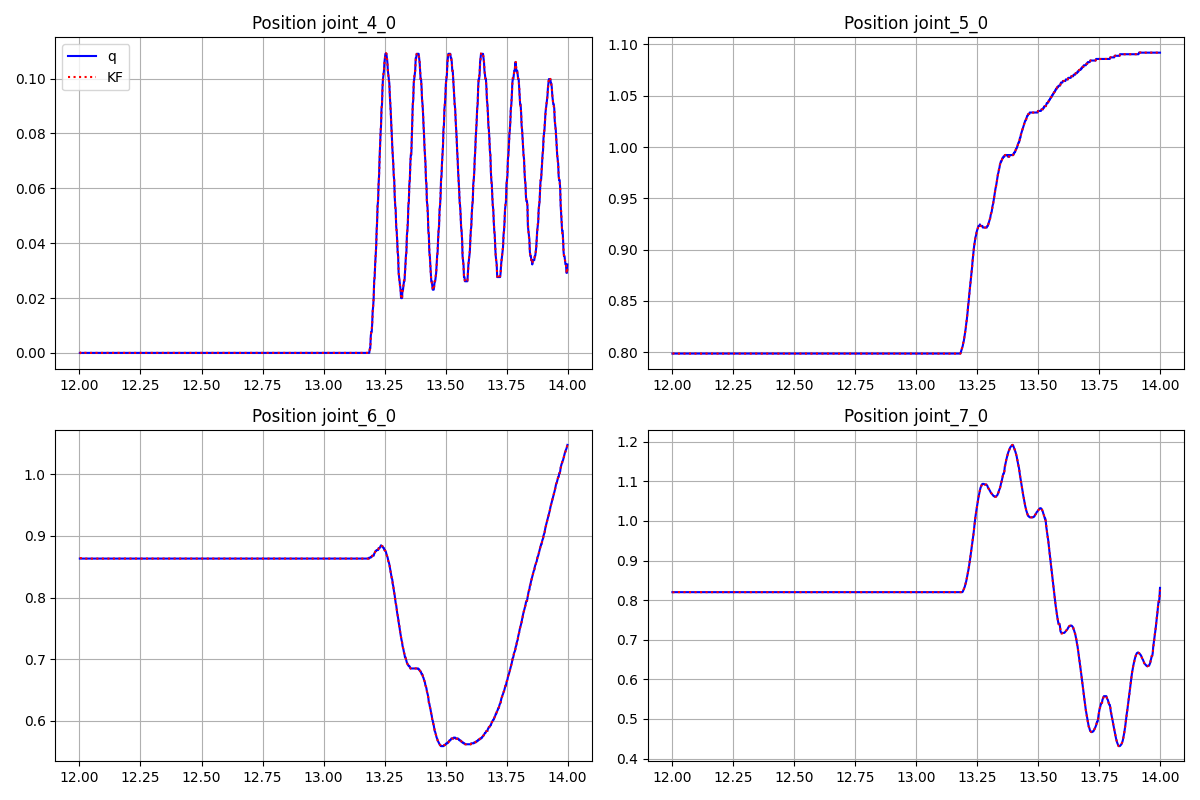

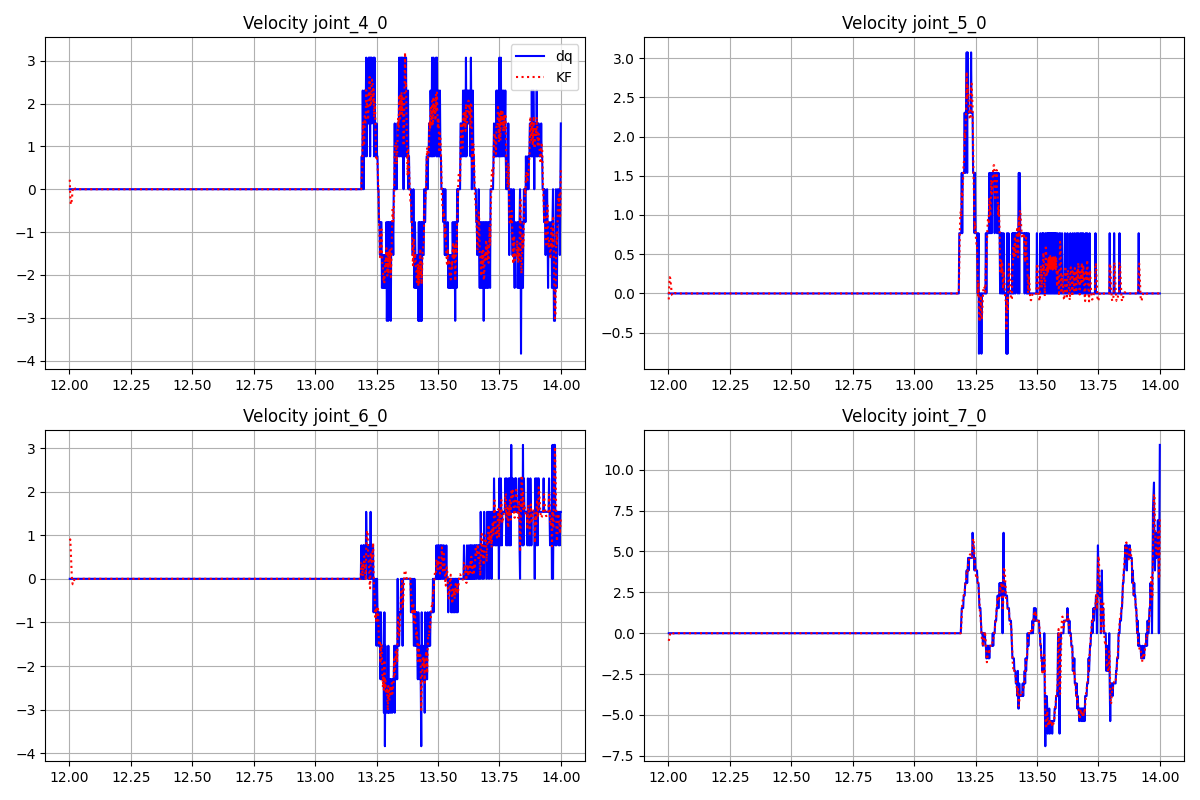

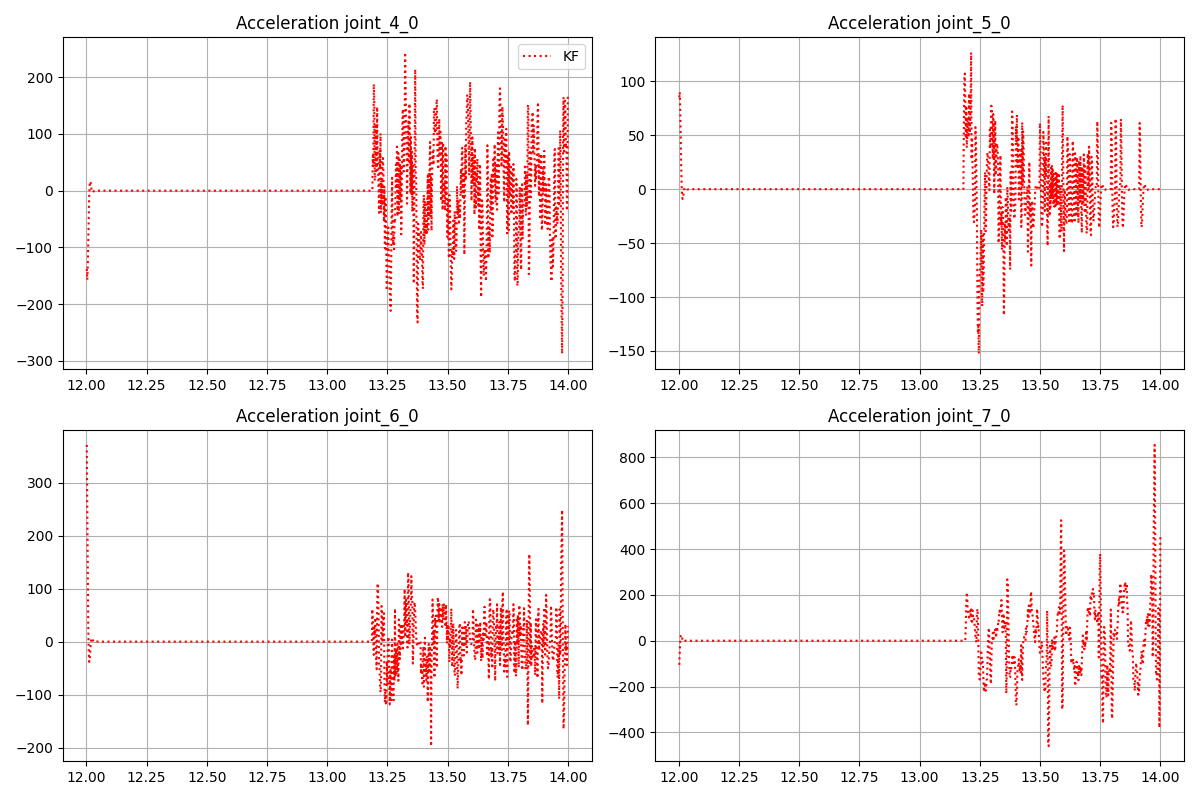

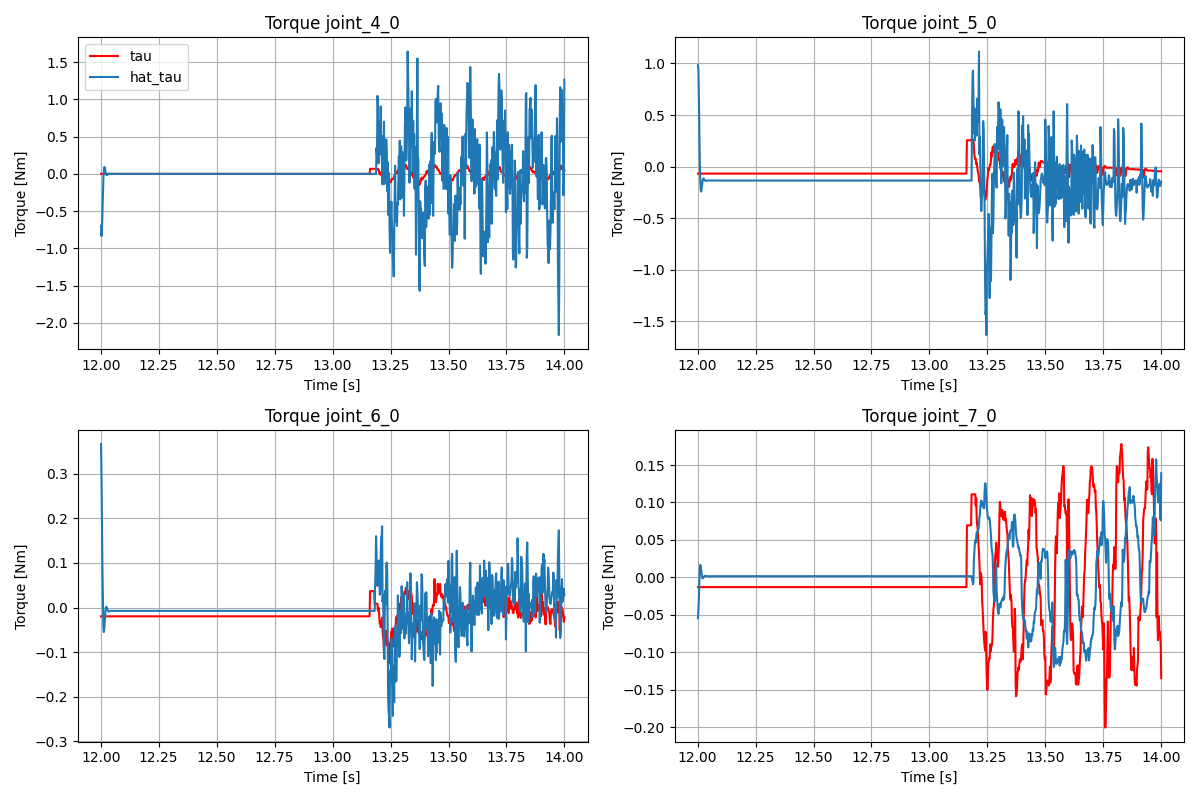

In [46]:
# =========================================================================================================================== Start
df = read_bag(BAG_PATH, topic_name='/allegroHand_0/joint_states', store=False)
#df2 = read_bag(BAG_PATH, topic_name='/allegroHand_0/torque_cmd',store=False)

t0 = df['t'].to_numpy()[0]


df = df[(df['t'] - t0 >= INTERVAL[0]) & (df['t'] - t0 <= INTERVAL[1])]
t_log = df['t'].to_numpy() - t0
q_log = df[[col for col in df.columns if col.startswith('pos_')]].to_numpy()
qd_log = df[[col for col in df.columns if col.startswith('vel_')]].to_numpy()
tau_log = df[[col for col in df.columns if col.startswith('eff_')]].to_numpy()

Dt = np.mean(np.diff(t_log))    # sampling period
F_s = 1.0 / Dt                  # sampling frequency
t_ori = t_log.copy()            # store original data
q_ori = q_log.copy()
qd_ori = qd_log.copy()
tau_ori = tau_log.copy()


"""
df2 = df2[(df2['t'] - t0 >= INTERVAL[0]) & (df2['t'] - t0 <= INTERVAL[1])]
t_log2 = df2['t'].to_numpy() - t0
q_log2 = df2[[col for col in df2.columns if col.startswith('pos_')]].to_numpy()
qd_log2 = df2[[col for col in df2.columns if col.startswith('vel_')]].to_numpy()
tau_log2 = df2[[col for col in df2.columns if col.startswith('eff_')]].to_numpy()
t_ori2 = t_log2.copy()            # store original data
q_ori2 = q_log2.copy()
qd_ori2 = qd_log2.copy()
tau_ori2 = tau_log2.copy()
"""

q_kf_filt = []
qd_kf_filt = []
qdd_kf_filt = []
q_tmp = []
qd_tmp = []
qdd_tmp = []

for i in range(len(t_log)):
#for i in range(5):
    for j in range(4):
        try:
            dt = t_log[i+1] - t_log[i]
        except:
            ft = t_log[i] - t_log[i-1]
        if i == 0:
            KFs[j].hat_x[0] = q_log[i][j]
        KFs[j].prediction(0.002)
        KFs[j].update(q_log[i][j])

        q_tmp.append(KFs[j].get_q())
        qd_tmp.append(KFs[j].get_qd())
        qdd_tmp.append(KFs[j].get_qdd())

    q_kf_filt.append(np.array(q_tmp))
    qd_kf_filt.append(np.array(qd_tmp))
    qdd_kf_filt.append(np.array(qdd_tmp))
    q_tmp = []
    qd_tmp = []
    qdd_tmp = []

q_kf_filt = np.array(q_kf_filt)
qd_kf_filt = np.array(qd_kf_filt)
qdd_kf_filt = np.array(qdd_kf_filt)

thunder_ahand.set_par_DYN(hat_Pi[:40])
delta_tau = []
for i in range(len(t_log)):
    #q =q_log[i,:]
    #dq = qd_log[i,:]
    #ddq = qdd_log[i,:]
    q = q_kf_filt[i,:]
    dq = qd_kf_filt[i,:]
    ddq = qdd_kf_filt[i,:]

    thunder_ahand.set_q(q)
    thunder_ahand.set_dq(dq)
    thunder_ahand.set_dqr(dq)
    thunder_ahand.set_ddqr(ddq)
    Y = thunder_ahand.get_reg_M() + thunder_ahand.get_reg_C() + thunder_ahand.get_reg_G()
    # add friction damping and static
    Y_d = np.diag(dq.flatten())
    Y_s = np.diag((2/(1+np.exp(-20*dq)) - 1).flatten())
    Y = np.hstack([Y, Y_d, Y_s])

    tau_est = np.array(Y @ hat_Pi).flatten()
    delta_tau.append(tau_log[i,:] - tau_est)
delta_tau = np.array(delta_tau)

# ===================================================================================================
# --- 2. Plot joint tau ---
plt.figure(figsize=(12,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.plot(t_log, q_ori[:,i], 'b', label='q')
    #plt.plot(t_log, q_log[:,i], 'r', label='q_filt')
    try:
        plt.plot(t_log2, q_log2[:,i], 'g', label='q_filt')
    except:
        pass
    plt.plot(t_log, q_kf_filt[:,i], 'r', linestyle='dotted', label='KF')
    #plt.plot(t_log, q_log[:,i] - e_log[:,i], 'b', linestyle='dotted', label='q_ref')# Plot joint desired trajectory
    #plt.hlines(JOINT_LIMITS[joint_indices[i], 0], t_log[0], t_log[-1], colors='k', linestyles='dotted', linewidth=1)
    #plt.hlines(JOINT_LIMITS[joint_indices[i], 1], t_log[0], t_log[-1], colors='k', linestyles='dotted', linewidth=1)
    plt.title(f'Position {JOINT_NAMES[i]}')
    plt.grid(True)
    if i==0:
        plt.legend()
plt.tight_layout()
plt.show()
if SAVE:
    plt.savefig(f"Joint_pos_{INTERVAL[0]}_{INTERVAL[1]}.png", dpi=300, bbox_inches='tight')
    print(f"Figure saved as Joint_pos_{INTERVAL[0]}_{INTERVAL[1]}.png")
# --- 1. Plot joint trajectories ---
plt.figure(figsize=(12,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.plot(t_log, qd_ori[:,i], 'b', label='dq')
    try:
        plt.plot(t_log2, qd_log2[:,i], 'g', label='q_filt')
    except:
        pass
    #plt.plot(t_log, qd_log[:,i], 'r', label='dq_filt')
    plt.plot(t_log, qd_kf_filt[:,i], 'r', linestyle='dotted', label='KF')
    plt.title(f'Velocity {JOINT_NAMES[i]}')
    plt.grid(True)
    if i==0:
        plt.legend()
plt.tight_layout()
plt.show()
if SAVE:
    plt.savefig(f"Joint_vel_{INTERVAL[0]}_{INTERVAL[1]}.png", dpi=300, bbox_inches='tight')
    print(f"Figure saved as Joint_vel_{INTERVAL[0]}_{INTERVAL[1]}.png")


plt.figure(figsize=(12,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.plot(t_log, qdd_kf_filt[:,i], 'r', linestyle='dotted', label='KF')
    plt.title(f'Acceleration {JOINT_NAMES[i]}')
    plt.grid(True)
    if i==0:
        plt.legend()
plt.tight_layout()
plt.show()
if SAVE:
    plt.savefig(f"Joint_acc_{INTERVAL[0]}_{INTERVAL[1]}.png", dpi=300, bbox_inches='tight')
    print(f"Figure saved as Joint_acc_{INTERVAL[0]}_{INTERVAL[1]}.png")

# --- 2. Plot joint tau ---
plt.figure(figsize=(12,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.plot(t_log, tau_log[:,i], 'r', label = 'tau')
    plt.plot(t_log, tau_log[:,i] - delta_tau[:,i], label = 'hat_tau')
    plt.xlabel('Time [s]')
    plt.ylabel('Torque [Nm]')
    plt.title(f'Torque {JOINT_NAMES[i]}')
    plt.grid(True)
    if i==0:
        plt.legend()
plt.tight_layout()
plt.show(block=False)
if SAVE:
    plt.savefig(f"Joint_torque_{INTERVAL[0]}_{INTERVAL[1]}.png", dpi=300, bbox_inches='tight')
    print(f"Figure saved as Joint_torque_{INTERVAL[0]}_{INTERVAL[1]}.png")
